# E11 Lab 5 & 6 — Air Weather Analysis

This notebook:
1. Loads and trims indoor and outdoor sensor datasets
2. Plots time-series for each data type (indoor, outdoor, overlaid)
3. Plots histograms comparing indoor vs outdoor for each data type
4. Computes means, standard deviations, and sigma separations
5. Compares our sensors with another group's sensors 
6. Compares data for 2 outdoor locations
7. Explores correlations between temperature and all other measured quantities


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
indoor_df = pd.read_csv('air_weather_indoors.csv')
outdoor_df = pd.read_csv('air_weather_outdoors.csv')
loc3_df = pd.read_csv('outdoor_data_2.csv')

# Trim indoor and outdoor: drop first 30 rows (original trimming)
for i in range(0, 30):
    indoor_df = indoor_df.drop(index=i)
    outdoor_df = outdoor_df.drop(index=i)
indoor_df = indoor_df.reset_index(drop=True)
outdoor_df = outdoor_df.reset_index(drop=True)

# loc3_df already trimmed at collection time (starts at t_s=73)

print("indoor rows:", len(indoor_df))
print("outdoor rows:", len(outdoor_df))
print("3rd location rows:", len(loc3_df))


indoor rows: 267
outdoor rows: 267
3rd location rows: 1113


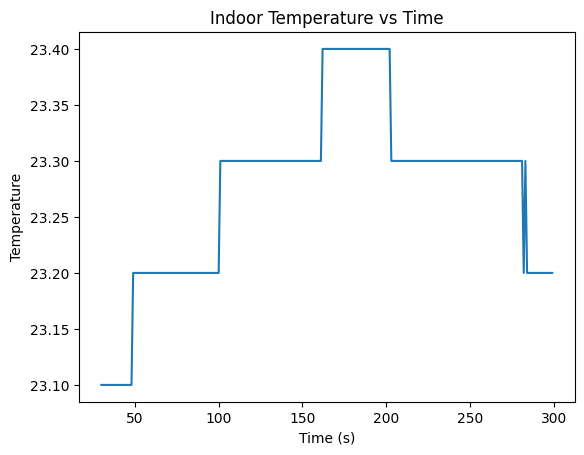

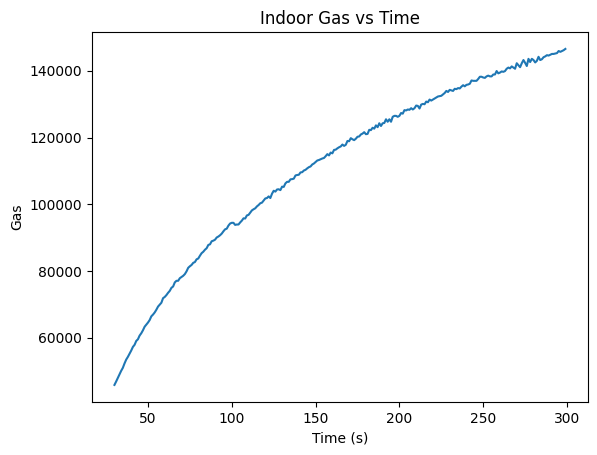

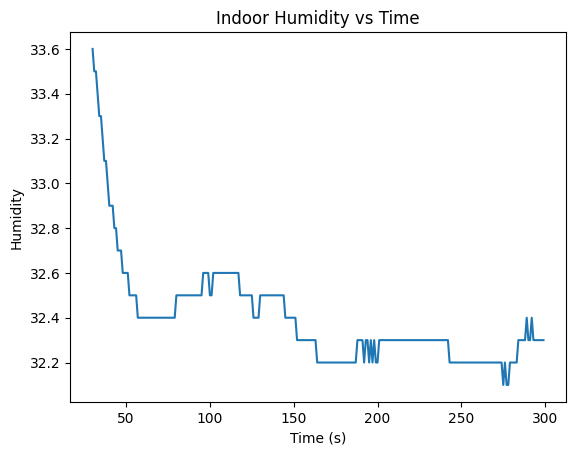

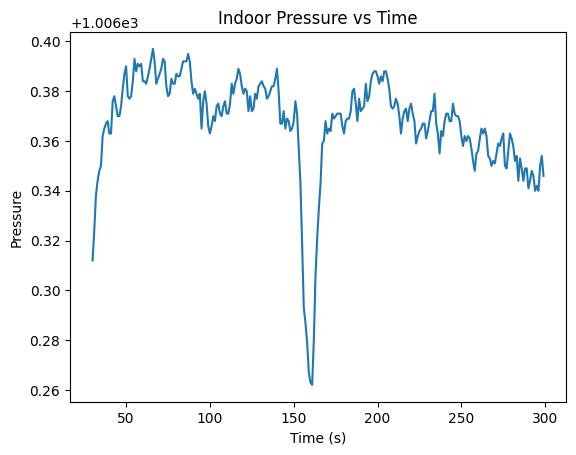

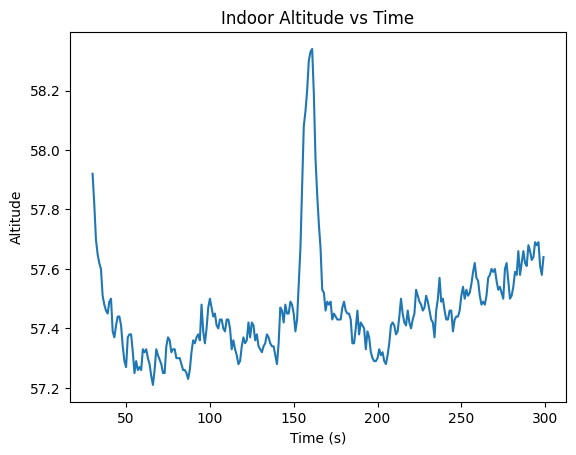

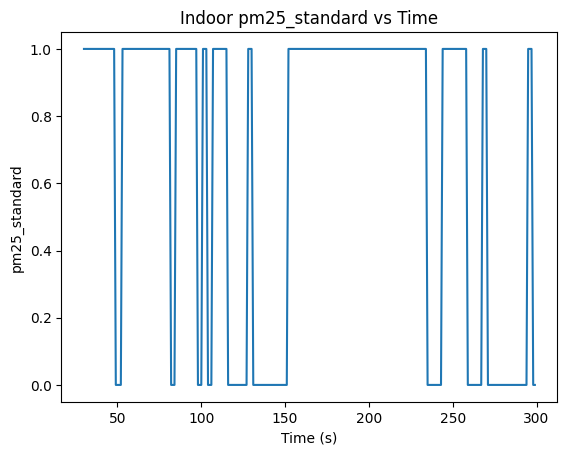

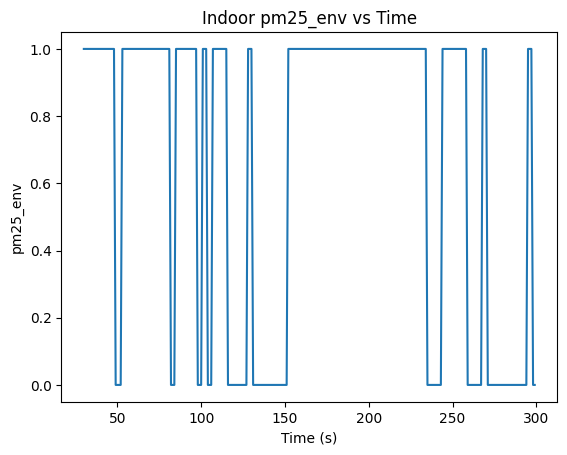

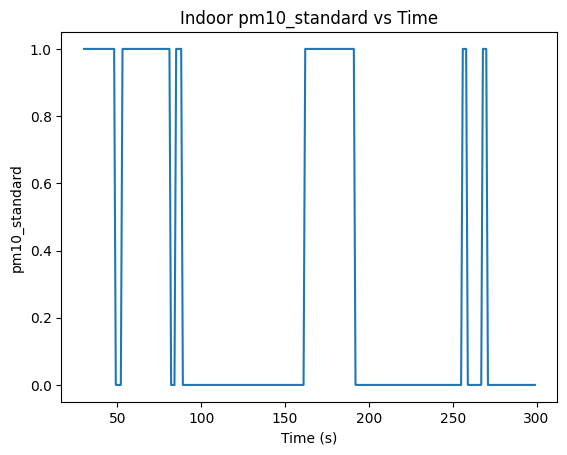

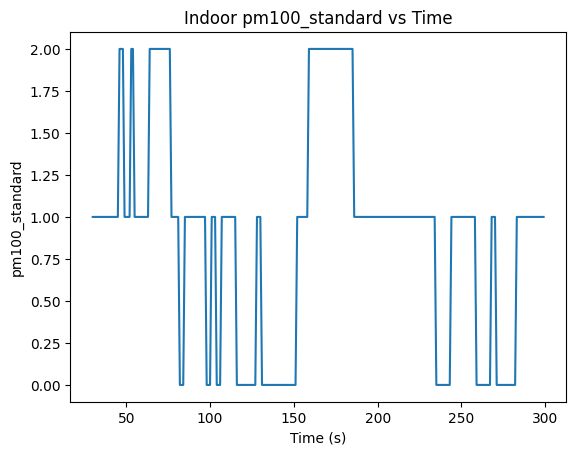

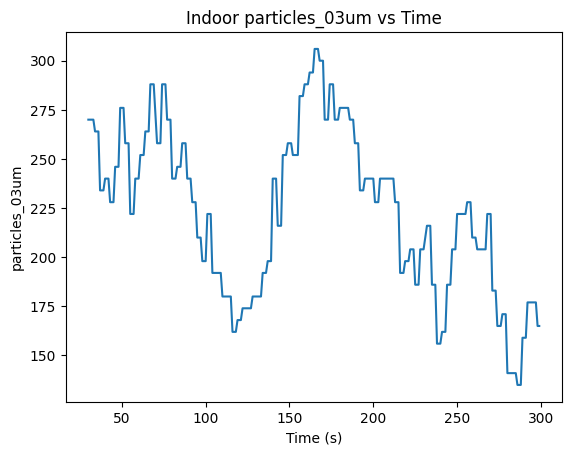

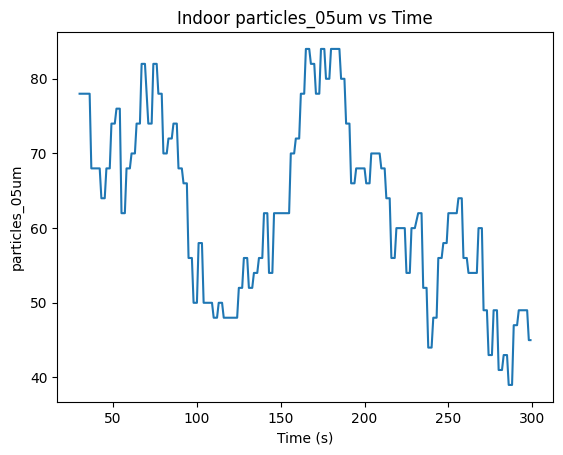

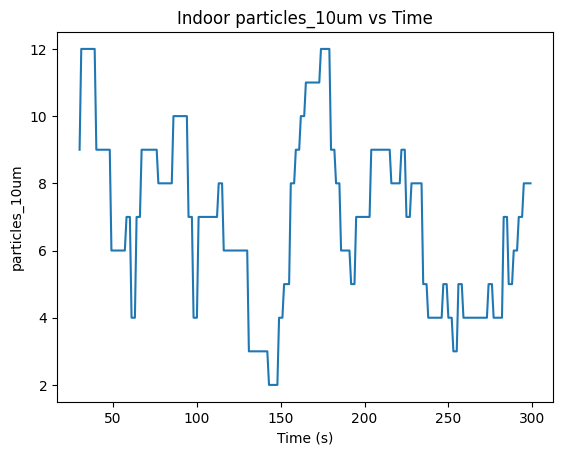

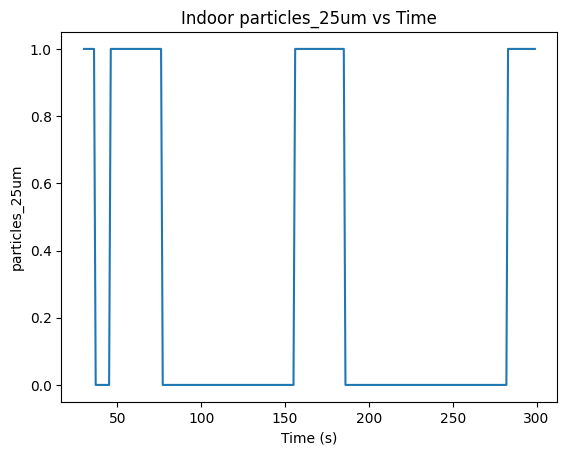

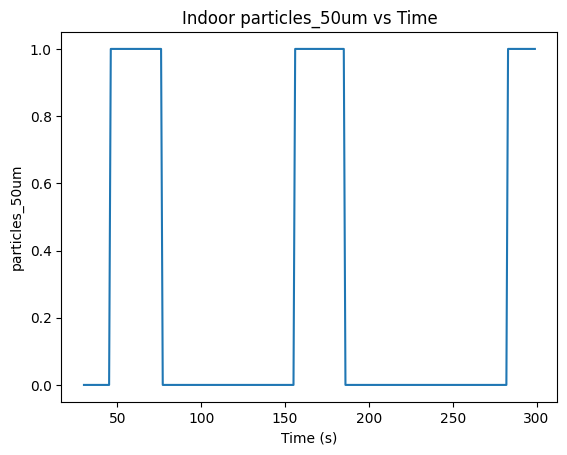

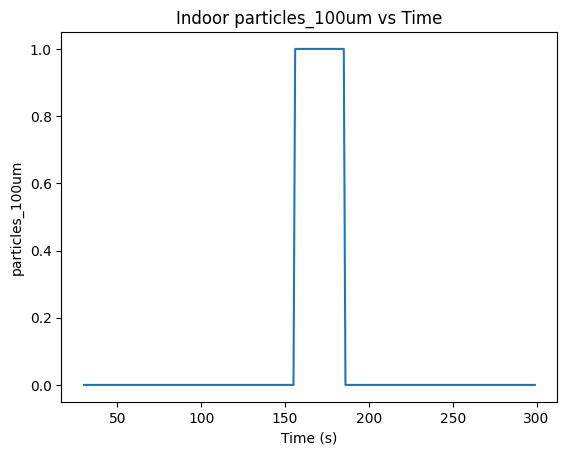

In [4]:
for i in range(1,len(indoor_df.columns)):
    plt.figure(i)
    plt.plot(indoor_df['t_s'],indoor_df[indoor_df.columns[i]]) 
    plt.xlabel('Time (s)')
    plt.ylabel(indoor_df.columns[i])
    plt.title(f'Indoor {indoor_df.columns[i]} vs Time')

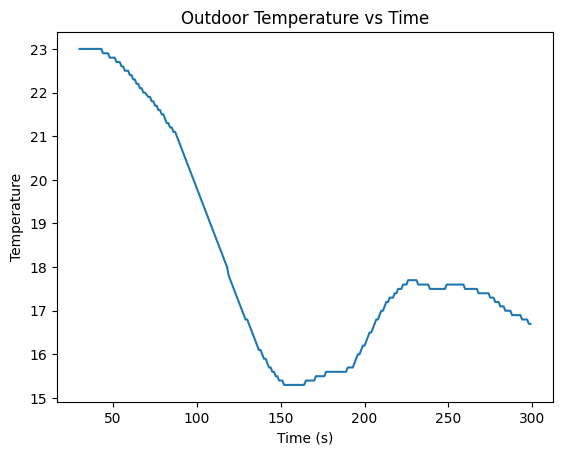

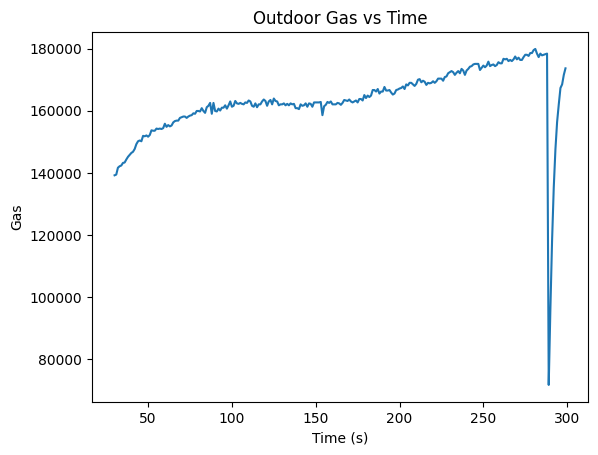

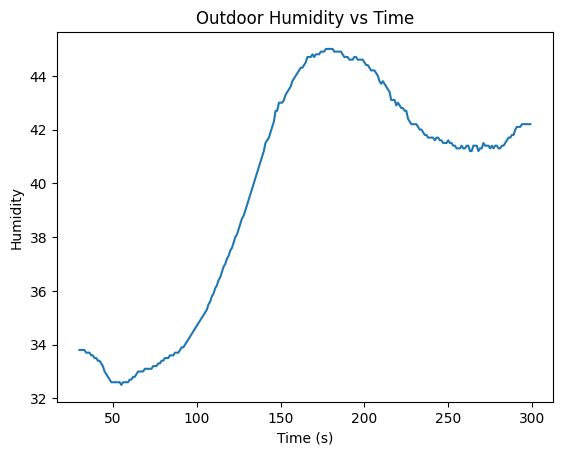

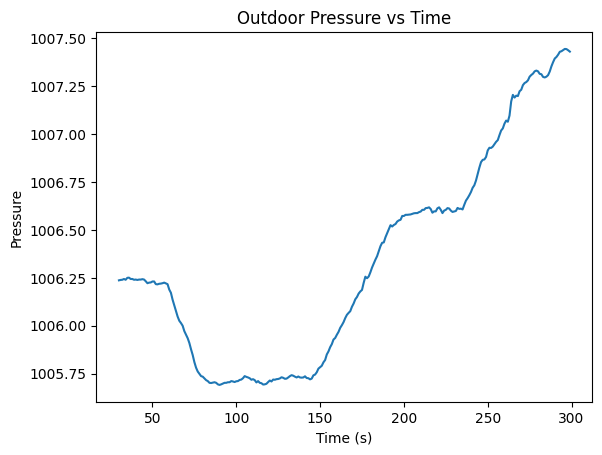

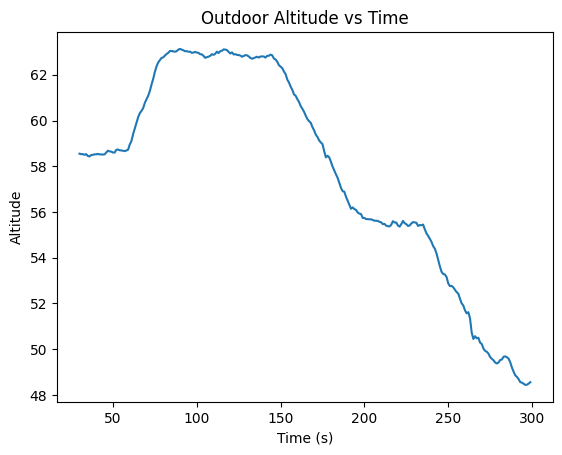

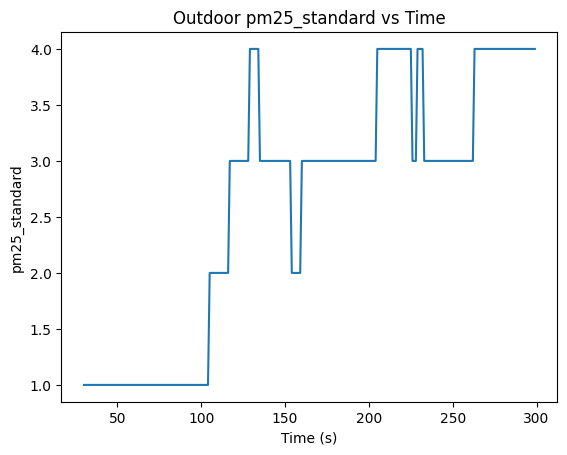

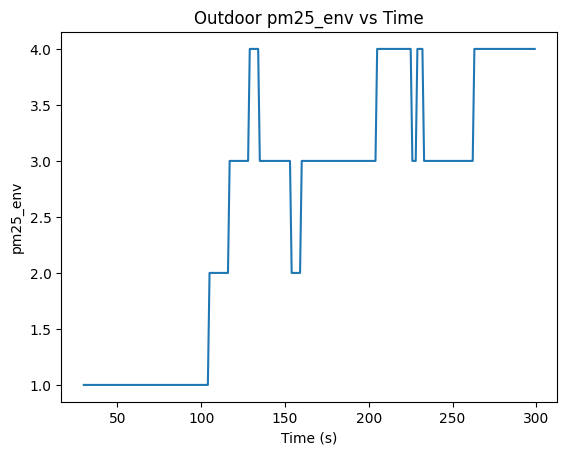

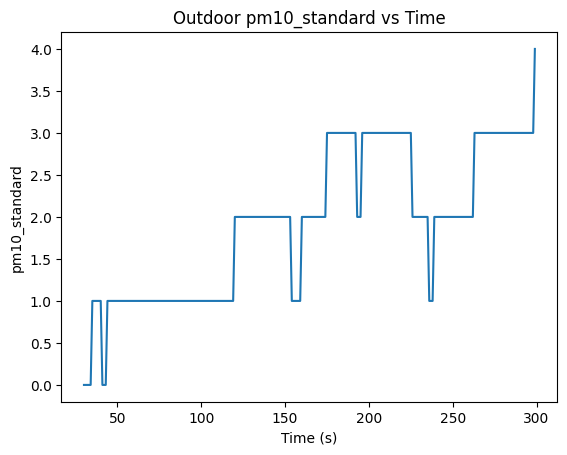

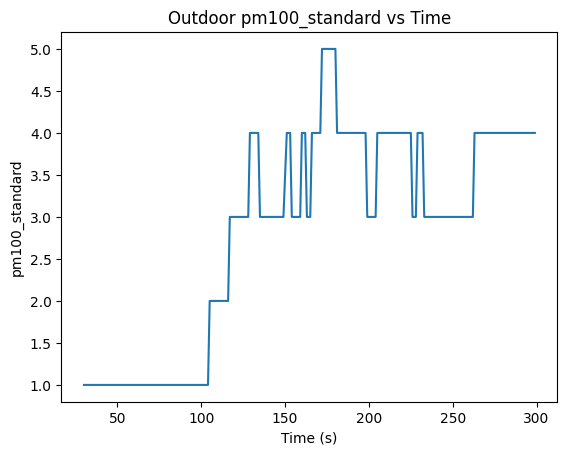

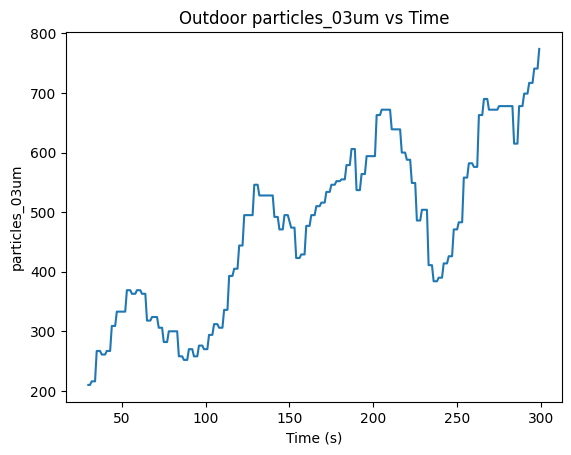

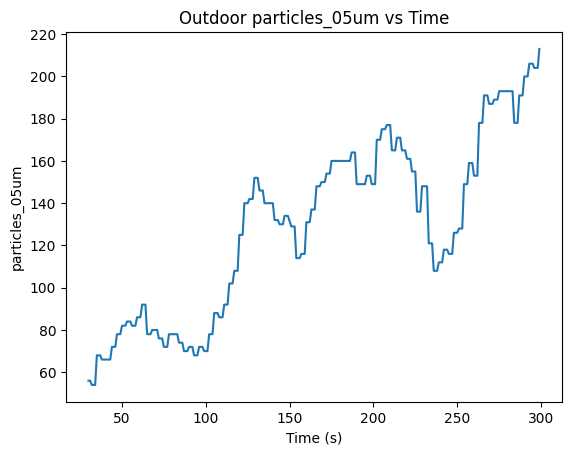

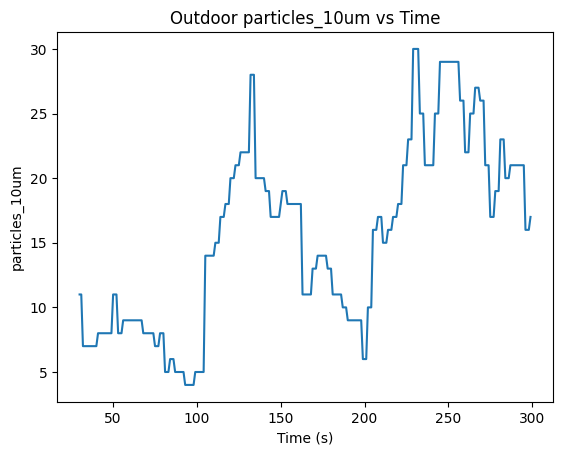

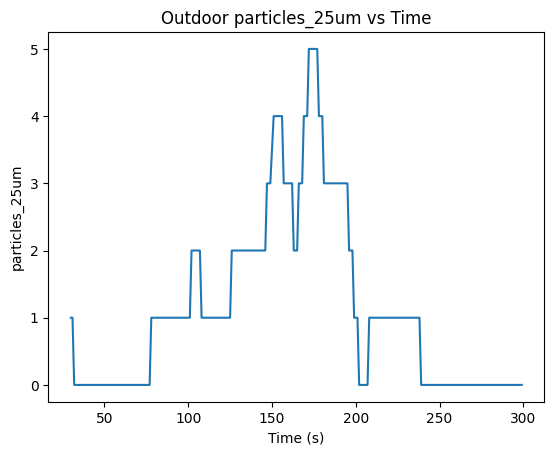

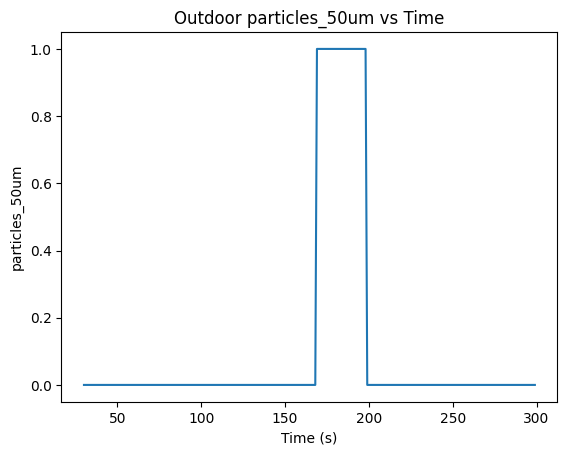

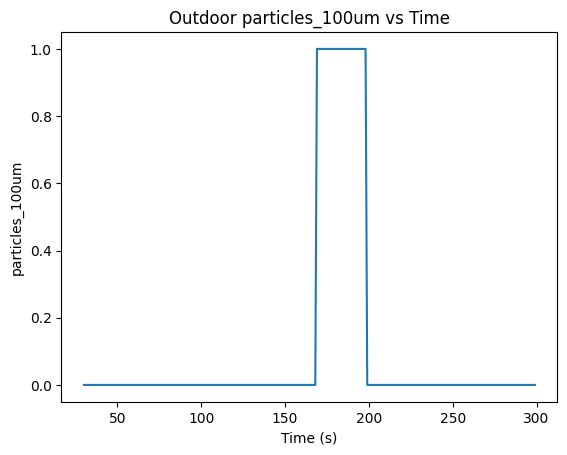

In [5]:
for i in range(1,len(outdoor_df.columns)):
    plt.figure(i)
    plt.plot(outdoor_df['t_s'],outdoor_df[outdoor_df.columns[i]]) 
    plt.xlabel('Time (s)')
    plt.ylabel(outdoor_df.columns[i])
    plt.title(f'Outdoor {outdoor_df.columns[i]} vs Time')

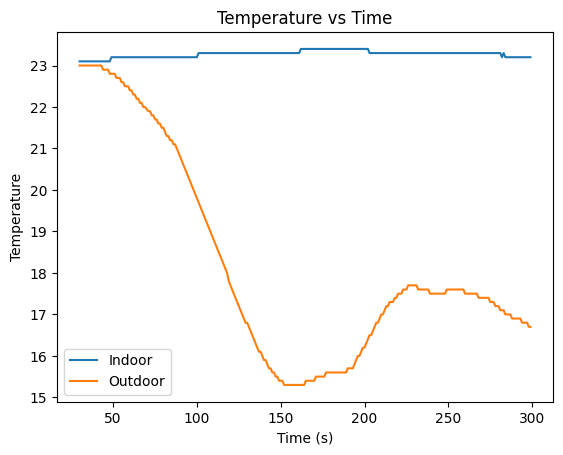

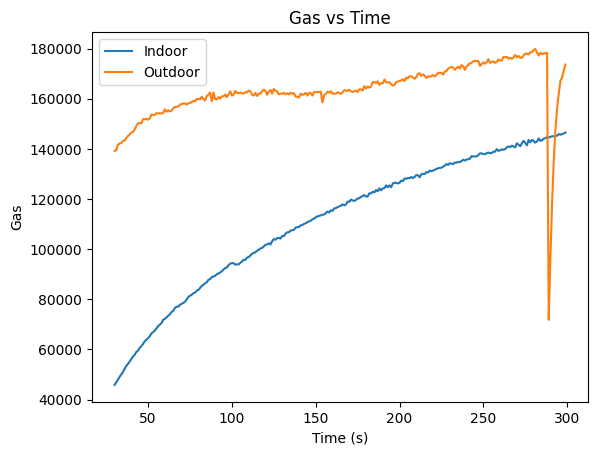

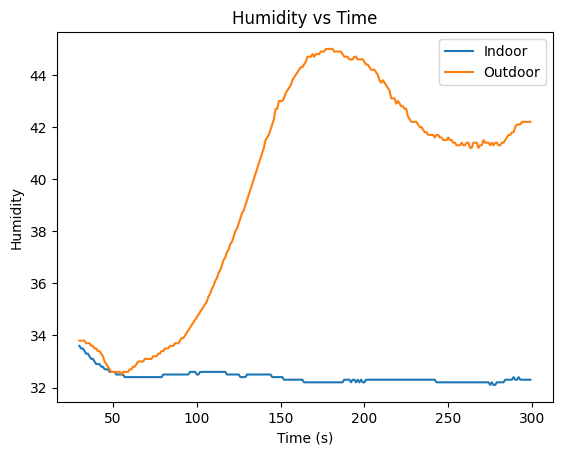

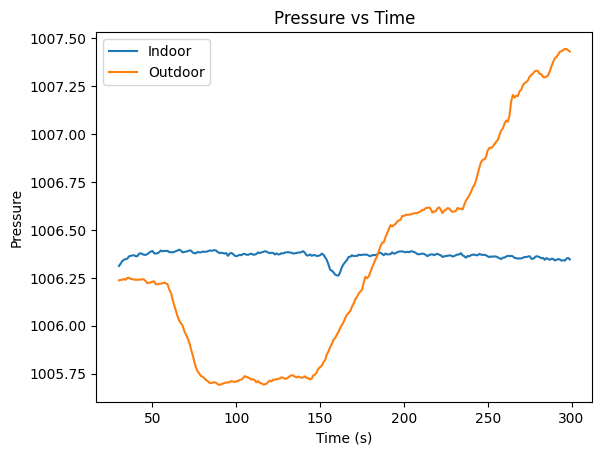

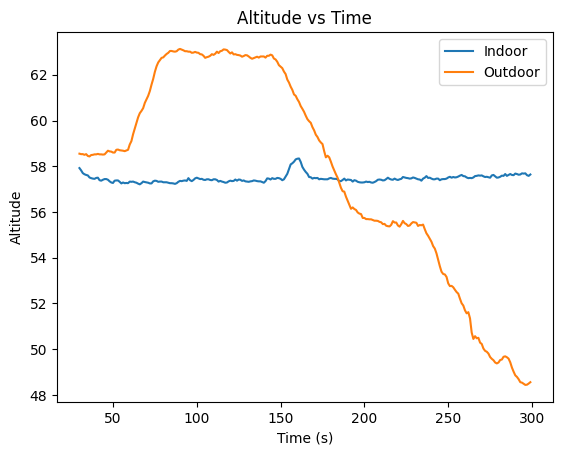

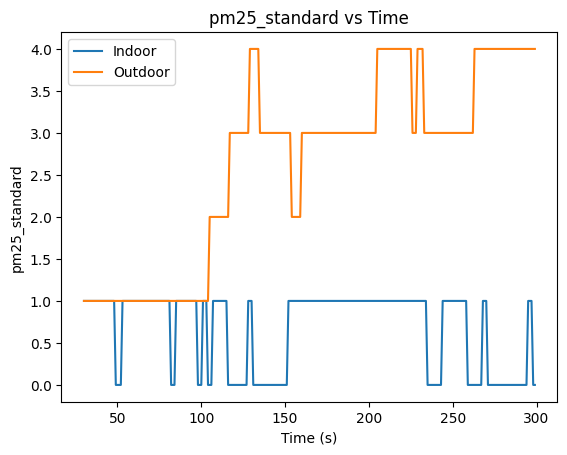

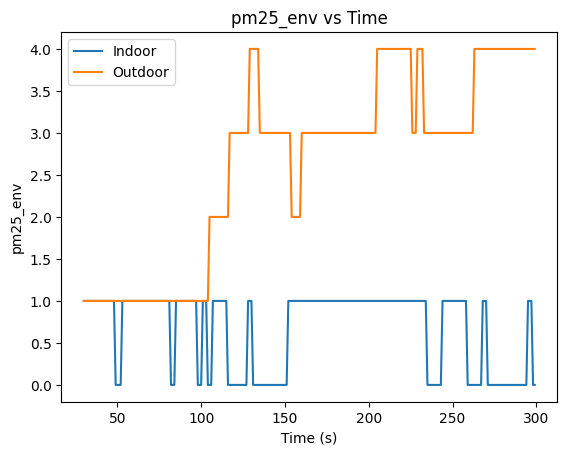

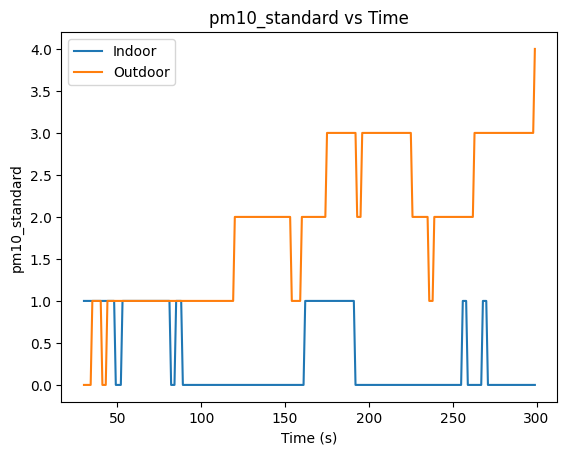

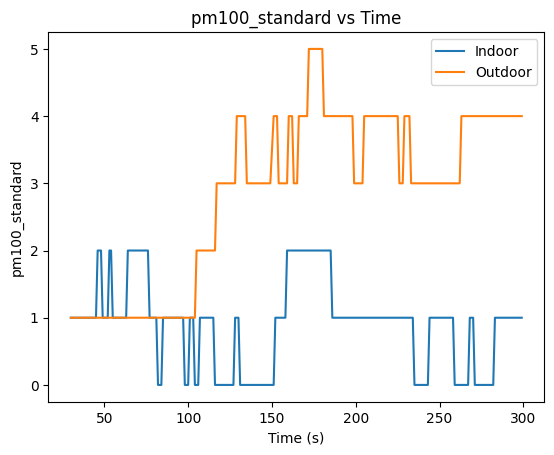

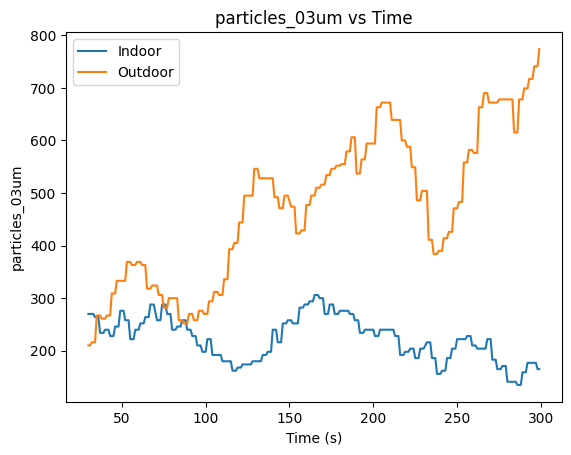

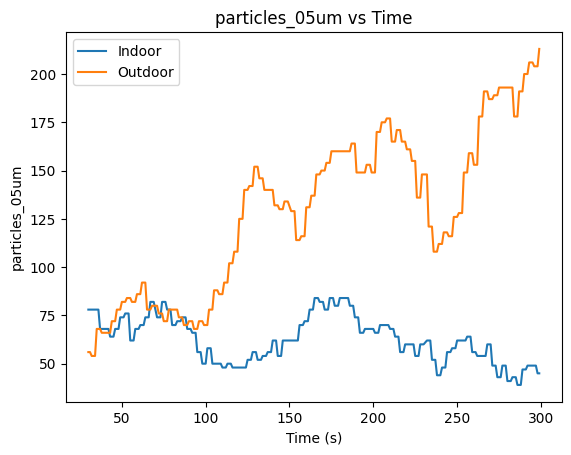

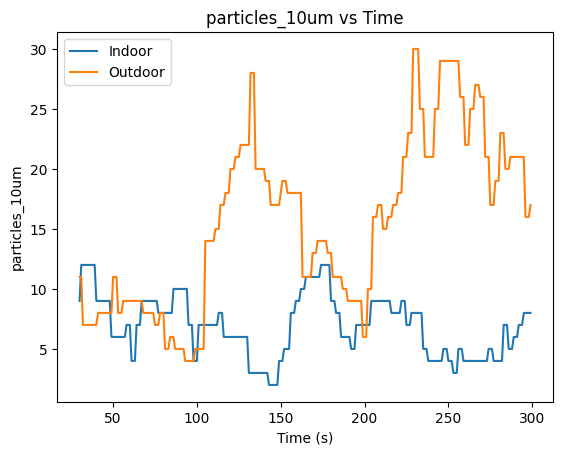

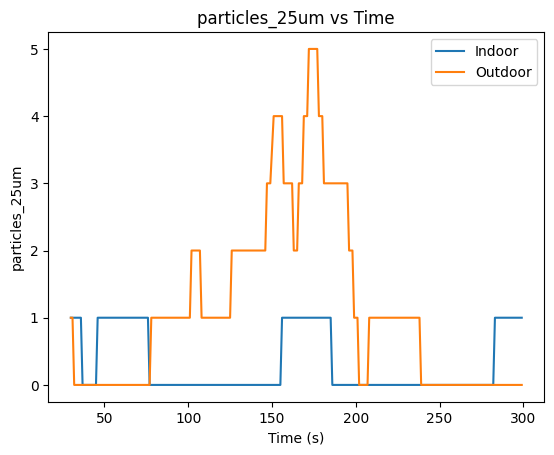

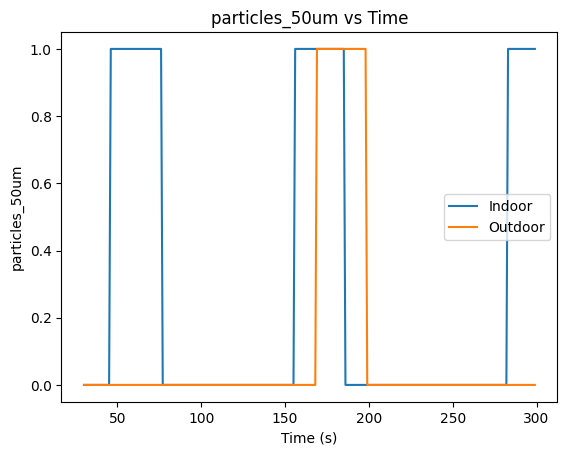

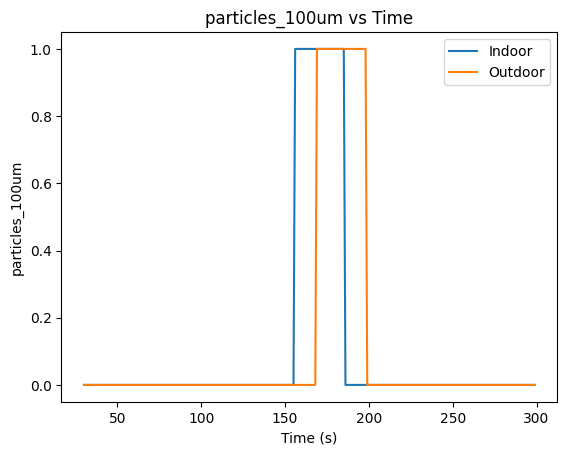

In [6]:
for i in range(1,len(indoor_df.columns)):
    plt.figure(i)
    plt.plot(indoor_df['t_s'],indoor_df[indoor_df.columns[i]],label="Indoor") 
    plt.plot(outdoor_df['t_s'],outdoor_df[outdoor_df.columns[i]], label="Outdoor")
    plt.xlabel('Time (s)')
    plt.ylabel(indoor_df.columns[i])
    plt.legend()
    plt.title(f'{indoor_df.columns[i]} vs Time')

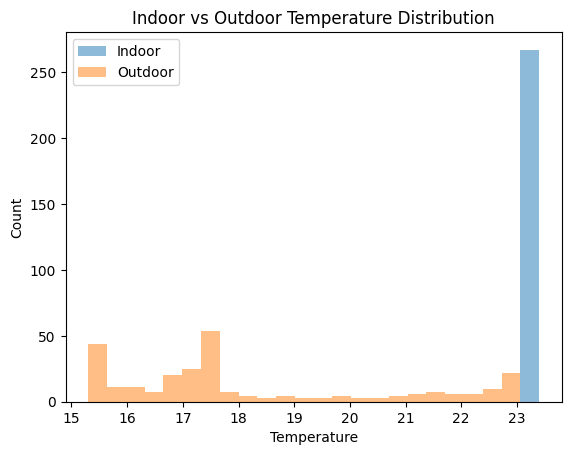

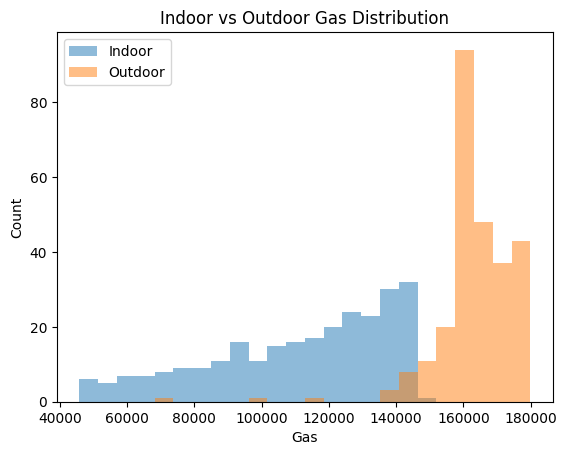

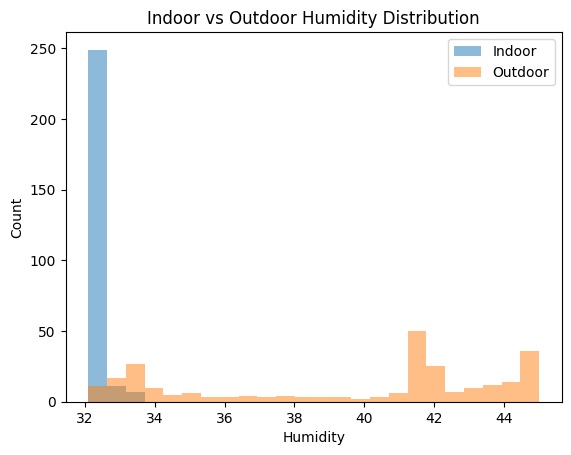

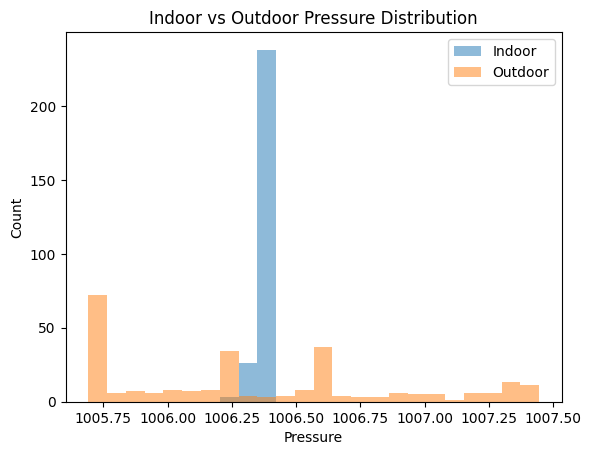

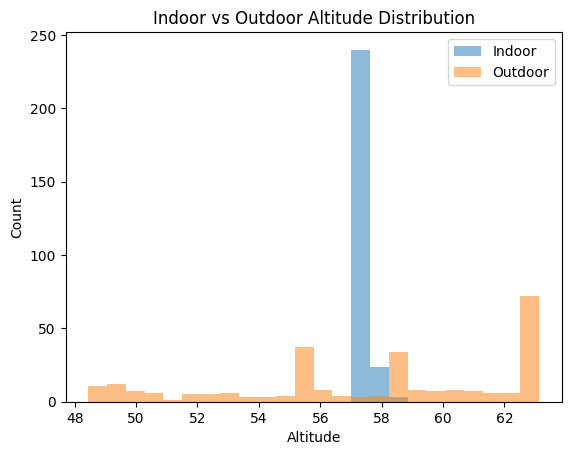

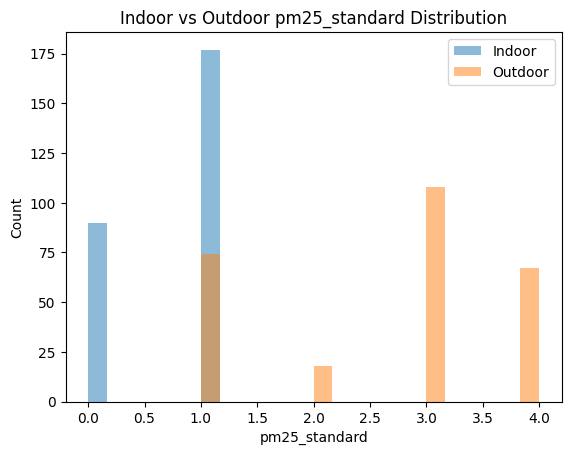

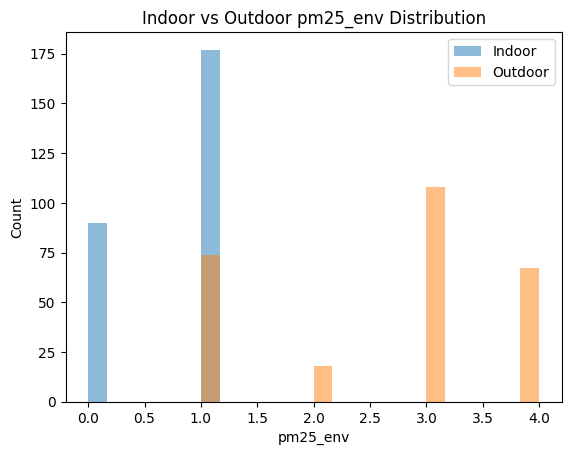

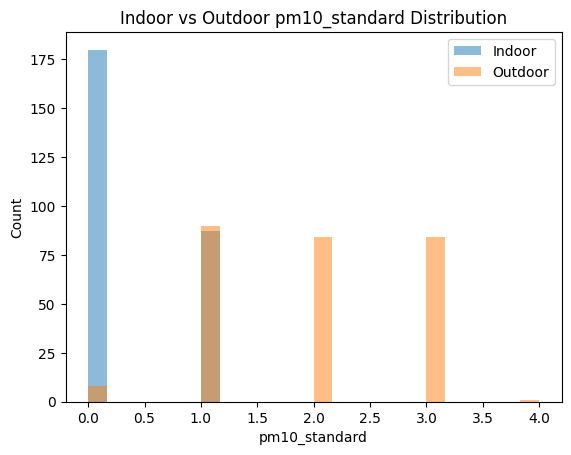

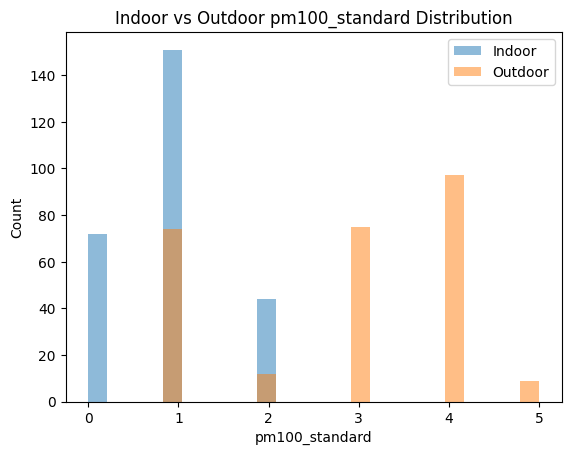

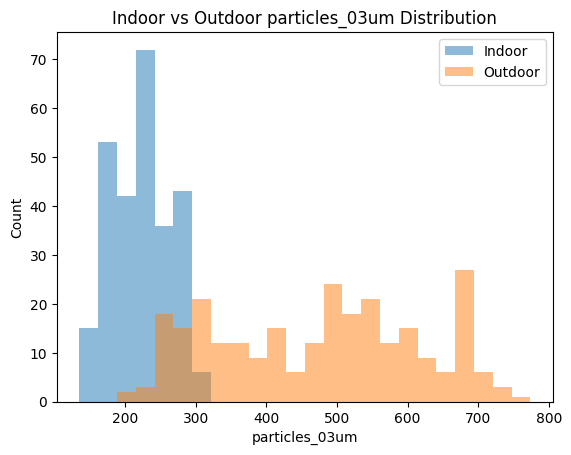

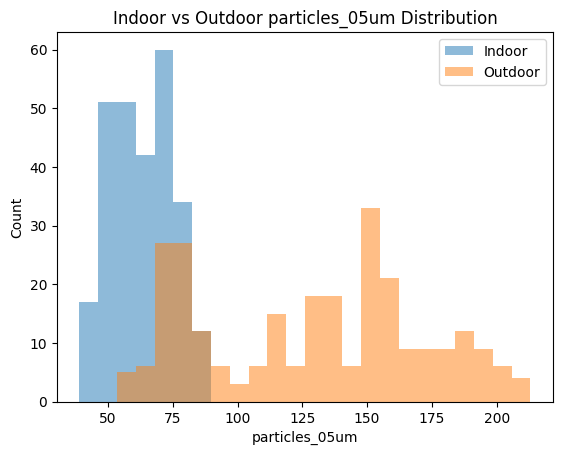

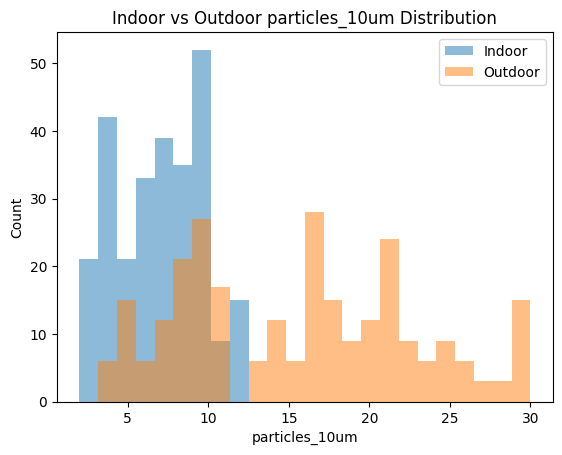

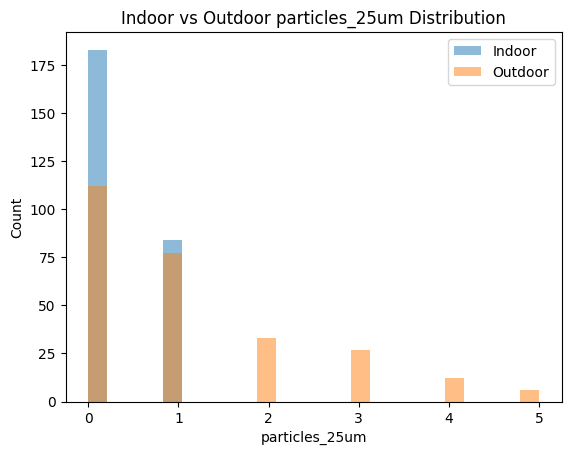

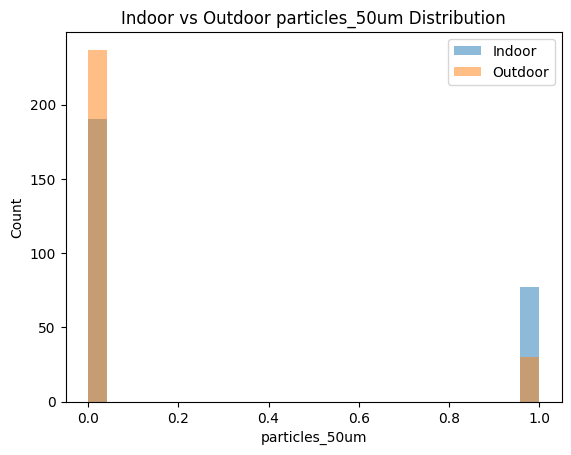

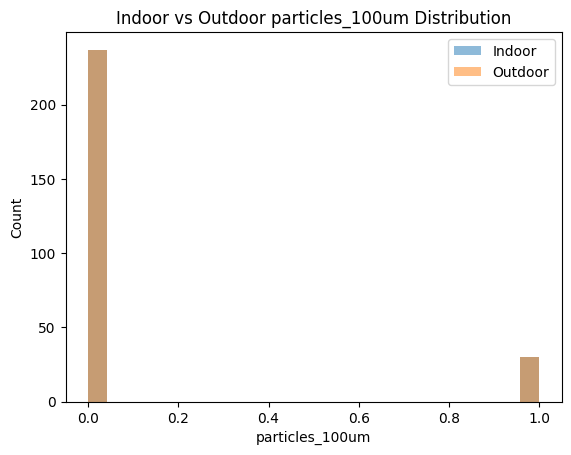

In [7]:
for i in range(1,len(indoor_df.columns)):
    combined_min = min(min(indoor_df[indoor_df.columns[i]]), min(outdoor_df[outdoor_df.columns[i]]))
    combined_max = max(max(indoor_df[indoor_df.columns[i]]), max(outdoor_df[outdoor_df.columns[i]]))
    shared_bins = np.linspace(combined_min,combined_max,25)
    plt.figure(i)
    plt.hist(indoor_df[indoor_df.columns[i]],label="Indoor", bins=shared_bins, alpha=0.5) 
    plt.hist(outdoor_df[outdoor_df.columns[i]], label="Outdoor", bins=shared_bins, alpha=0.5)
    plt.xlabel(indoor_df.columns[i])
    plt.ylabel('Count')
    plt.legend()
    plt.title(f'Indoor vs Outdoor {indoor_df.columns[i]} Distribution')


In [8]:
print("=== Indoor vs Outdoor Statistical Comparison ===\n")
for i in range(1,len(indoor_df.columns)):
    col = indoor_df.columns[i]
    indoor_mean = np.mean(indoor_df[col])
    outdoor_mean = np.mean(outdoor_df[col])
    indoor_std = np.std(indoor_df[col])
    outdoor_std = np.std(outdoor_df[col])
    # Uncertainty on the mean (standard error) = std / sqrt(N)
    indoor_uncertainty = indoor_std / np.sqrt(len(indoor_df))
    outdoor_uncertainty = outdoor_std / np.sqrt(len(outdoor_df))
    # Sigma separation = |mean_in - mean_out| / combined uncertainty
    sigma_separation = abs(indoor_mean - outdoor_mean) / np.sqrt(indoor_uncertainty**2 + outdoor_uncertainty**2)
    print(f'{col}:')
    print(f'  Indoor  mean = {indoor_mean:.4f}  std = {indoor_std:.4f}  mean uncertainty (σ_mean) = {indoor_uncertainty:.5f}')
    print(f'  Outdoor mean = {outdoor_mean:.4f}  std = {outdoor_std:.4f}  mean uncertainty (σ_mean) = {outdoor_uncertainty:.5f}')
    print(f'  Separation = {sigma_separation:.2f} σ  (>3σ statistically significant)\n')


=== Indoor vs Outdoor Statistical Comparison ===

Temperature:
  Indoor  mean = 23.2757  std = 0.0796  mean uncertainty (σ_mean) = 0.00487
  Outdoor mean = 18.2011  std = 2.4720  mean uncertainty (σ_mean) = 0.15128
  Separation = 33.53 σ  (>3σ statistically significant)

Gas:
  Indoor  mean = 111145.7978  std = 26905.3282  mean uncertainty (σ_mean) = 1646.57935
  Outdoor mean = 163442.6479  std = 11384.8959  mean uncertainty (σ_mean) = 696.74432
  Separation = 29.25 σ  (>3σ statistically significant)

Humidity:
  Indoor  mean = 32.3996  std = 0.2363  mean uncertainty (σ_mean) = 0.01446
  Outdoor mean = 39.6052  std = 4.3440  mean uncertainty (σ_mean) = 0.26585
  Separation = 27.06 σ  (>3σ statistically significant)

Pressure:
  Indoor  mean = 1006.3673  std = 0.0212  mean uncertainty (σ_mean) = 0.00130
  Outdoor mean = 1006.3355  std = 0.5479  mean uncertainty (σ_mean) = 0.03353
  Separation = 0.95 σ  (>3σ statistically significant)

Altitude:
  Indoor  mean = 57.4618  std = 0.1771  me

## Lab 6 Step 1 Discussion — Indoor vs Outdoor Statistical Comparison

**Mean uncertainty:** The uncertainty on the mean (standard error) is $\sigma_{\bar{x}} = \sigma / \sqrt{N}$, not the spread $\sigma$ of the distribution itself. With ~267 samples per dataset, even small physical differences become statistically resolvable.

**Sigma separation:** $n_\sigma = |\bar{x}_{in} - \bar{x}_{out}| / \sqrt{\sigma_{\bar{x},in}^2 + \sigma_{\bar{x},out}^2}$. A separation $> 3\sigma$ means $< 0.3\%$ probability the two datasets are from the same true distribution.

**Results summary:**

| Quantity | Indoor mean | Outdoor mean | Separation | Significant? |
|---|---|---|---|---|
| Temperature (°C) | 23.3 | 18.2 | 33.5 σ | ✓ Yes |
| Humidity (%) | 32.4 | 39.6 | 27.1 σ | ✓ Yes |
| Pressure (hPa) | 1006.37 | 1006.34 | 0.95 σ | ✗ No |
| Gas (Ω) | 111 k | 163 k | 29.3 σ | ✓ Yes |
| PM2.5 (µg/m³) | 0.66 | 2.63 | 26.1 σ | ✓ Yes |
| Particles 0.3µm | 223 | 474 | 27.4 σ | ✓ Yes |

Most quantities are statistically distinguishable at far beyond 3σ. Pressure (0.95σ) is not significant, which is expected, since atmospheric pressure is the same indoors and outdoors. Indoor temperature is ~5°C warmer (building heating), and indoor humidity is lower (~32% vs ~40%), consistent with heated indoor air having lower relative humidity. Outdoor air has roughly 2–4× more particulate matter across all size bins.

**Gaussian / CLT:** With ~267 samples, the CLT applies well. Even for non-Gaussian distributions (e.g., discrete particle counts), the distribution of the mean converges to Gaussian, making the σ-separation test valid.

---
## Lab 6 Step 2 — Comparing Sensors (Other Group)

The other group's CSV uses a different column format (timestamp, fewer particle bins), so we align the comparable channels below.

In [9]:
# Load other group's data
other_indoor_df = pd.read_csv('other_group_inside_data.csv')
other_outdoor_df = pd.read_csv('other_group_outside_data.csv')

# Convert their timestamp column to elapsed seconds
for df in [other_indoor_df, other_outdoor_df]:
    df['t_s'] = pd.to_datetime(df['time'], format='%H:%M:%S')
    t0 = df['t_s'].iloc[0]
    df['t_s'] = (df['t_s'] - t0).dt.total_seconds()

# Trim first 60 seconds from other group data
other_indoor_df  = other_indoor_df[other_indoor_df['t_s'] >= 60].reset_index(drop=True)
other_outdoor_df = other_outdoor_df[other_outdoor_df['t_s'] >= 60].reset_index(drop=True)

# Map comparable column names: (our_col, their_col, label)
comparable_cols = [
    ('Temperature', 'Temperature', 'Temperature'),
    ('Humidity',    'Humidity',    'Humidity'),
    ('Pressure',    'Pressure',    'Pressure'),
    ('Gas',         'Gas',         'Gas'),
    ('particles_03um', 'Particles > 0.3um / 0.1L air', 'Particles 0.3um'),
]

print("Other group indoor data shape:", other_indoor_df.shape)
print("Other group outdoor data shape:", other_outdoor_df.shape)
print(other_indoor_df.head(2))


Other group indoor data shape: (241, 8)
Other group outdoor data shape: (303, 8)
       time  Particles > 0.3um / 0.1L air  Temperature     Gas   Humidity  \
0  15:15:28                           144    19.376484  193290  35.255172   
1  15:15:29                           144    19.373359  194374  34.924767   

      Pressure   Altitude   t_s  
0  1006.752715  54.235318  60.0  
1  1006.754952  54.216593  61.0  


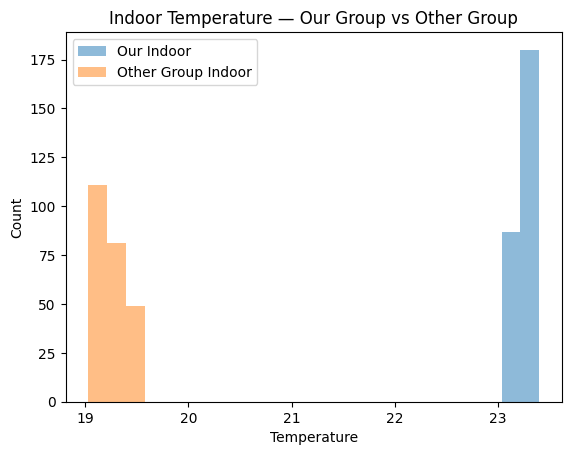

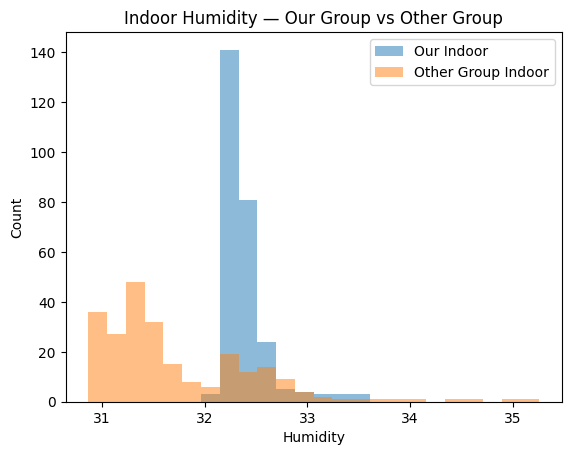

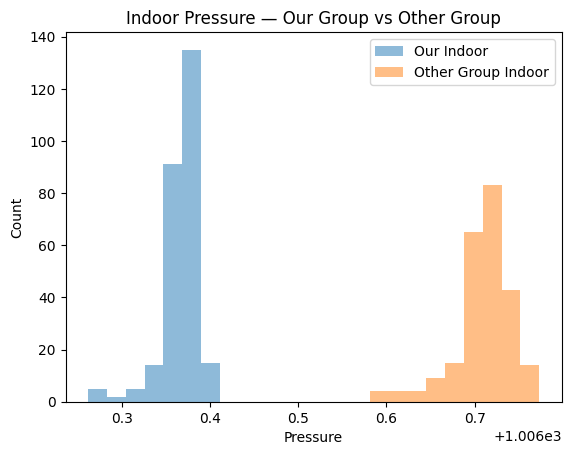

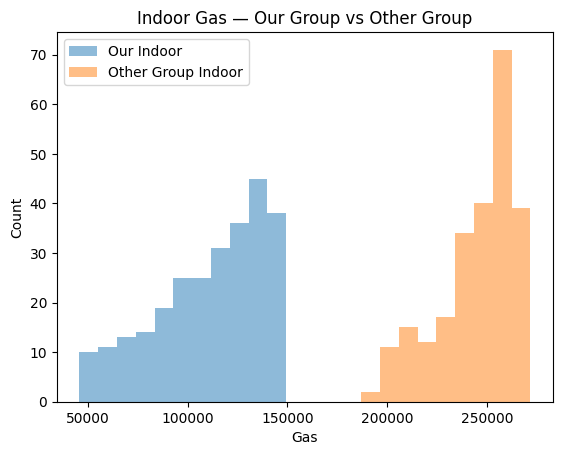

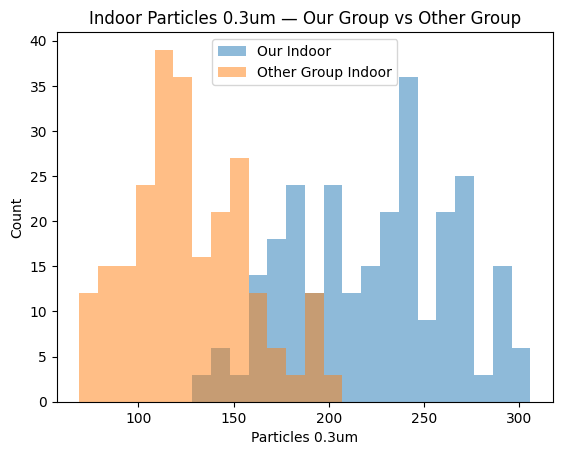

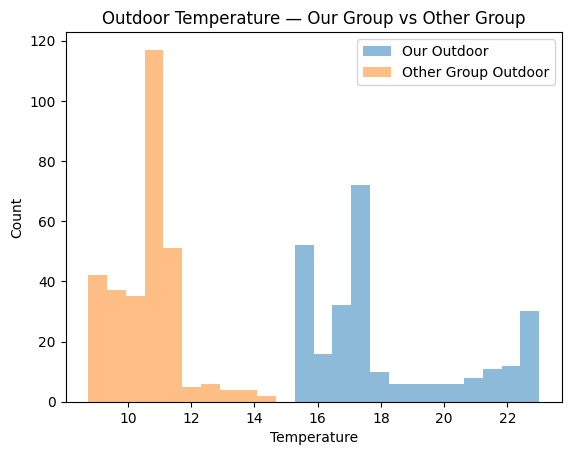

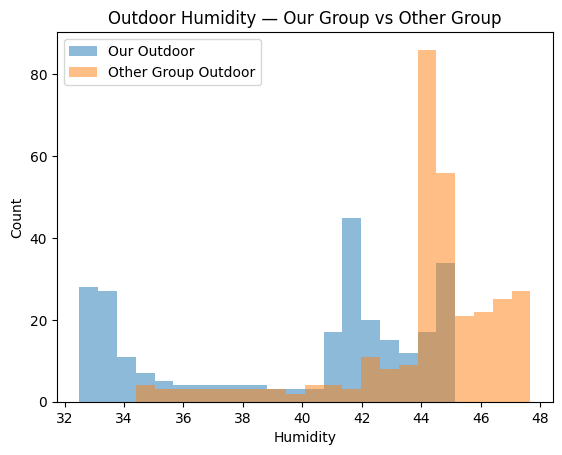

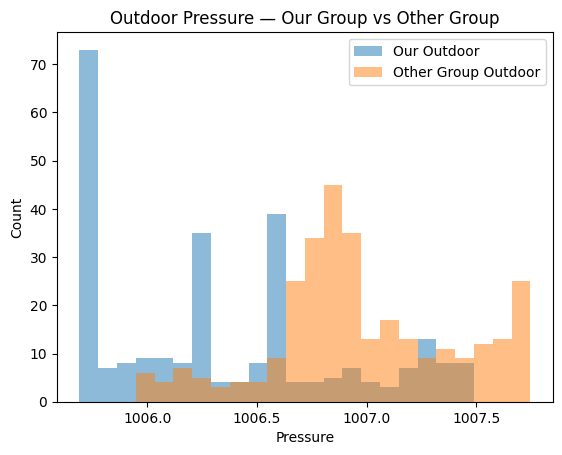

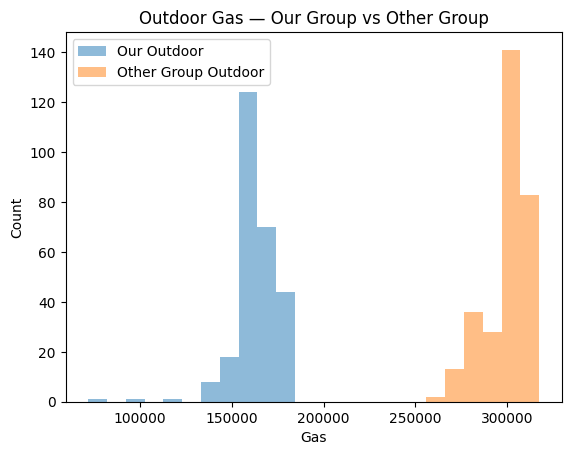

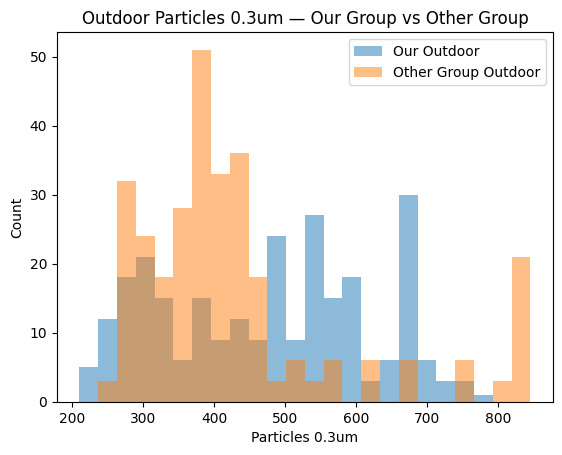

In [10]:
# --- Histogram comparison: our indoor vs other group's indoor ---
fig_offset = 100
for idx, (our_col, their_col, label) in enumerate(comparable_cols):
    our_vals   = indoor_df[our_col]
    their_vals = other_indoor_df[their_col]
    combined_min = min(our_vals.min(), their_vals.min())
    combined_max = max(our_vals.max(), their_vals.max())
    bins = np.linspace(combined_min, combined_max, 25)
    plt.figure(fig_offset + idx)
    plt.hist(our_vals,   bins=bins, alpha=0.5, label='Our Indoor')
    plt.hist(their_vals, bins=bins, alpha=0.5, label='Other Group Indoor')
    plt.xlabel(label)
    plt.ylabel('Count')
    plt.legend()
    plt.title(f'Indoor {label} — Our Group vs Other Group')

# --- Histogram comparison: our outdoor vs other group's outdoor ---
fig_offset2 = 200
for idx, (our_col, their_col, label) in enumerate(comparable_cols):
    our_vals   = outdoor_df[our_col]
    their_vals = other_outdoor_df[their_col]
    combined_min = min(our_vals.min(), their_vals.min())
    combined_max = max(our_vals.max(), their_vals.max())
    bins = np.linspace(combined_min, combined_max, 25)
    plt.figure(fig_offset2 + idx)
    plt.hist(our_vals,   bins=bins, alpha=0.5, label='Our Outdoor')
    plt.hist(their_vals, bins=bins, alpha=0.5, label='Other Group Outdoor')
    plt.xlabel(label)
    plt.ylabel('Count')
    plt.legend()
    plt.title(f'Outdoor {label} — Our Group vs Other Group')


In [11]:
# --- Statistical comparison: our indoor vs other indoor, our outdoor vs other outdoor ---
def stats_compare(vals_a, vals_b, label_a, label_b, quantity):
    mean_a = np.mean(vals_a);  std_a = np.std(vals_a);  unc_a = std_a / np.sqrt(len(vals_a))
    mean_b = np.mean(vals_b);  std_b = np.std(vals_b);  unc_b = std_b / np.sqrt(len(vals_b))
    sep = abs(mean_a - mean_b) / np.sqrt(unc_a**2 + unc_b**2)
    print(f'{quantity}:')
    print(f'  {label_a}: mean={mean_a:.4f}  std={std_a:.4f}  σ_mean={unc_a:.5f}')
    print(f'  {label_b}: mean={mean_b:.4f}  std={std_b:.4f}  σ_mean={unc_b:.5f}')
    print(f'  Separation = {sep:.2f} σ\n')

print("=== Our Indoor vs Other Group Indoor ===\n")
for our_col, their_col, label in comparable_cols:
    stats_compare(indoor_df[our_col], other_indoor_df[their_col],
                  'Our Indoor', 'Other Indoor', label)

print("=== Our Outdoor vs Other Group Outdoor ===\n")
for our_col, their_col, label in comparable_cols:
    stats_compare(outdoor_df[our_col], other_outdoor_df[their_col],
                  'Our Outdoor', 'Other Outdoor', label)


=== Our Indoor vs Other Group Indoor ===

Temperature:
  Our Indoor: mean=23.2757  std=0.0796  σ_mean=0.00487
  Other Indoor: mean=19.2409  std=0.1675  σ_mean=0.01079
  Separation = 340.76 σ

Humidity:
  Our Indoor: mean=32.3996  std=0.2363  σ_mean=0.01446
  Other Indoor: mean=31.7379  std=0.7645  σ_mean=0.04925
  Separation = 12.89 σ

Pressure:
  Our Indoor: mean=1006.3673  std=0.0212  σ_mean=0.00130
  Other Indoor: mean=1006.7094  std=0.0315  σ_mean=0.00203
  Separation = 142.14 σ

Gas:
  Our Indoor: mean=111145.7978  std=26905.3282  σ_mean=1646.57935
  Other Indoor: mean=245446.6598  std=19269.5380  σ_mean=1241.26006
  Separation = 65.13 σ

Particles 0.3um:
  Our Indoor: mean=223.0674  std=41.5202  σ_mean=2.54100
  Other Indoor: mean=126.5851  std=30.5256  σ_mean=1.96633
  Separation = 30.03 σ

=== Our Outdoor vs Other Group Outdoor ===

Temperature:
  Our Outdoor: mean=18.2011  std=2.4720  σ_mean=0.15128
  Other Outdoor: mean=10.6025  std=0.9807  σ_mean=0.05634
  Separation = 47.07

### Step 2 Discussion — What the Sensor Comparison Reveals

**Temperature:** Our indoor sensor reads 23.3°C vs. the other group's 19.2°C — a 4.1°C offset, 341σ separated. Both groups were in the same room, so this is a real systematic bias (accuracy error) between sensors.

**Humidity:** Smaller offset (12.9σ), our sensor reads 32.4% vs. their 33.7%.

**Pressure:** 142σ separation at only 0.34 hPa difference. Both sensors are very precise, so even a tiny absolute offset is statistically resolved.

**Gas (raw resistance):** 65σ separation, our sensor reads ~111 kΩ vs. their ~245 kΩ indoors. The BME680 measures raw metal-oxide resistance with a large manufacturing-dependent baseline. The two sensors detect the same relative changes but cannot be directly compared on an absolute scale without individual calibration.

**Particle counts (0.3µm):** 30σ separation, our sensor reads higher (223 vs. 127 per 0.1L). The PMS5003 also has unit-to-unit sensitivity variation.

**Outdoor comparison:** The large temperature separation (47σ, 7.6°C) likely reflects different recording times in addition to sensor offset.

**Conclusion:** The sensors show good **precision** (consistent readings within each dataset) but meaningful **accuracy differences** in absolute values, especially for temperature and gas resistance. This is typical of uncalibrated MEMS sensors is useful for detecting changes but requiring individual calibration to agree on absolute values across units.

---
## Lab 6 Step 3 — More Locations (Strawberry Creek, UC Berkeley Campus)

A third dataset (`outdoor_data_2.csv`) was collected at **Strawberry Creek on the UC Berkeley campus** a pedestrian greenway running through campus, away from major roads and vehicle traffic. We chose this site expecting that its low-traffic, natural environment might yield different air quality compared to our original outdoor site near the lab building entrance, which is closer to street-level traffic.

Below we compare this Strawberry Creek dataset with the original outdoor data using time-series plots, histograms, and the same statistical analysis as Steps 1 and 2.


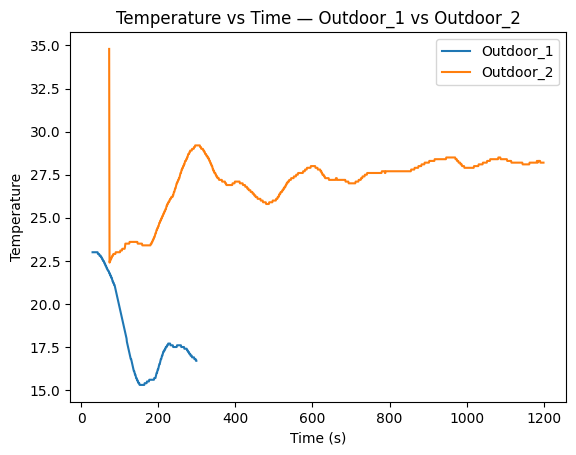

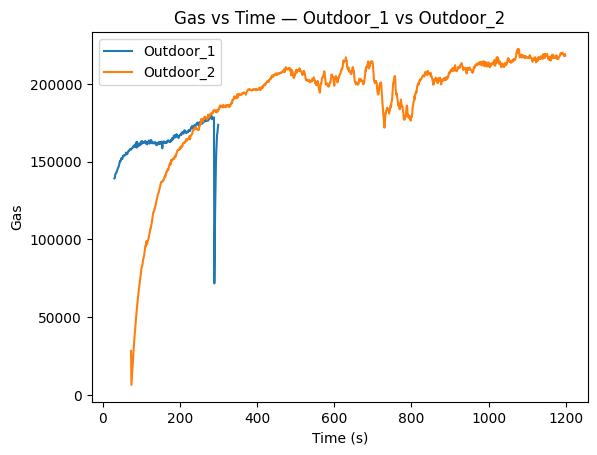

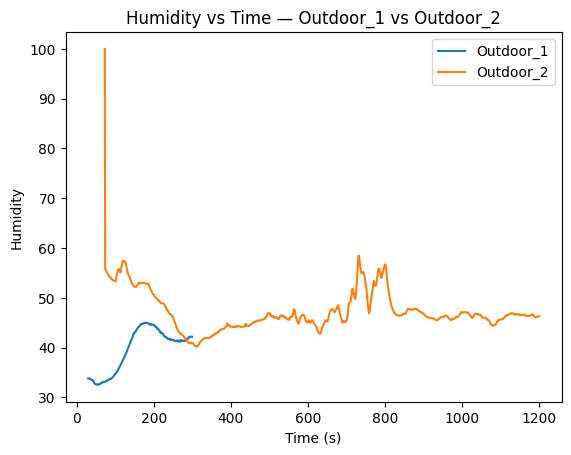

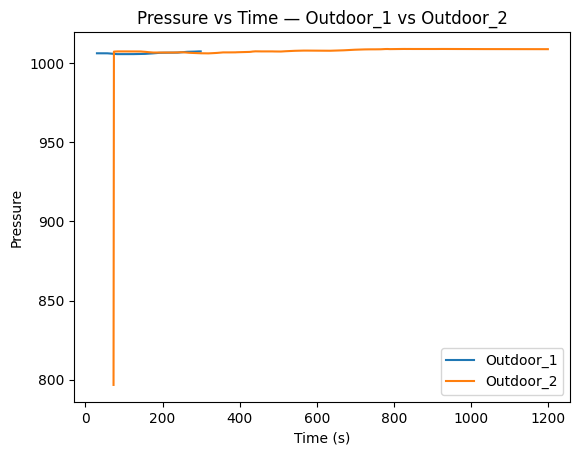

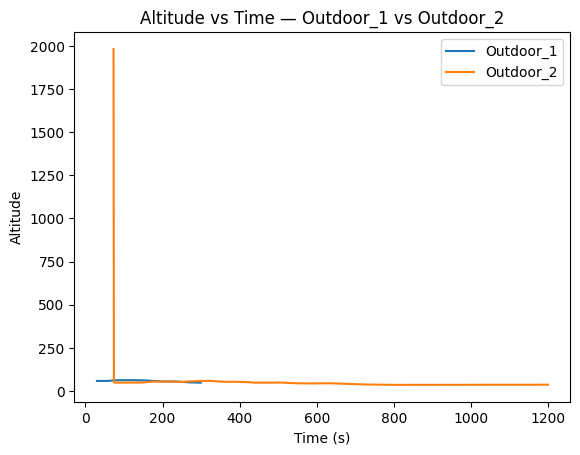

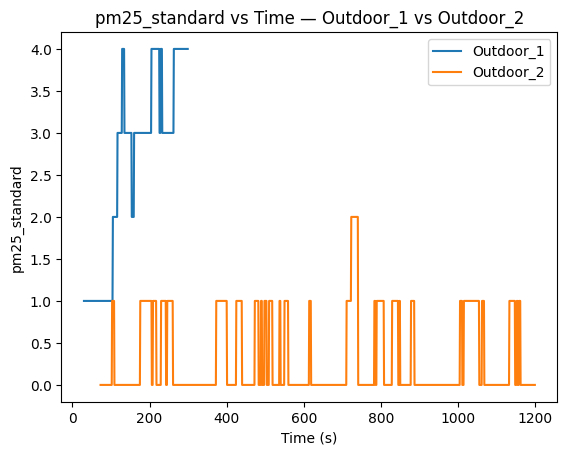

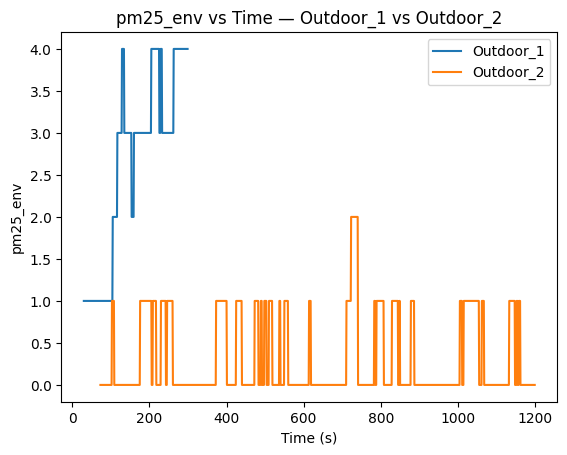

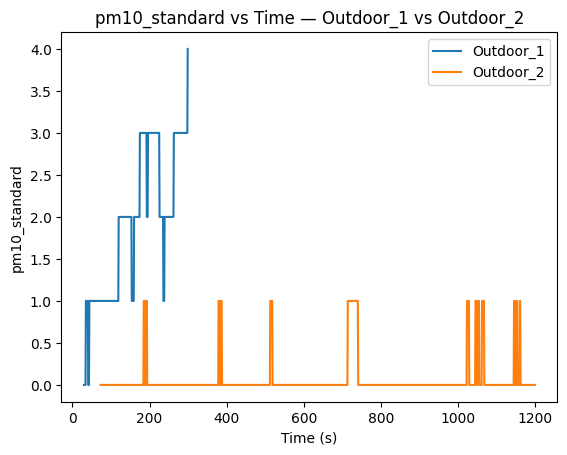

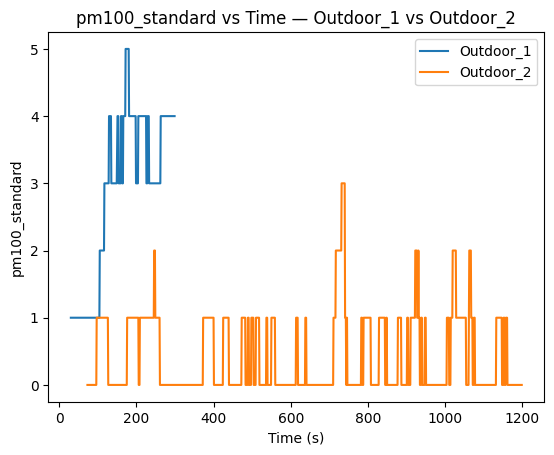

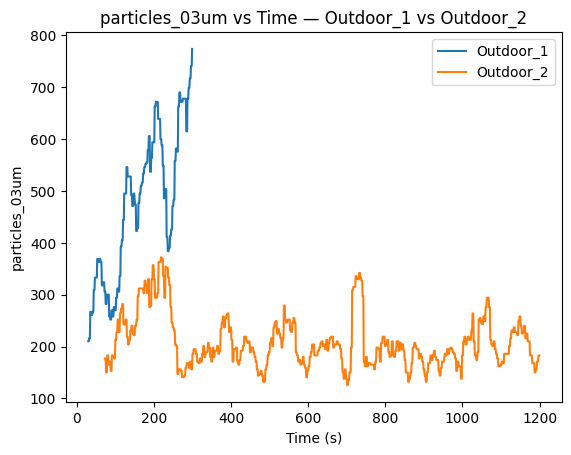

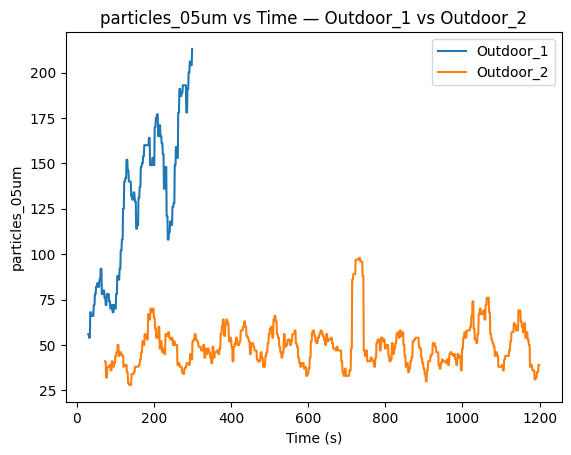

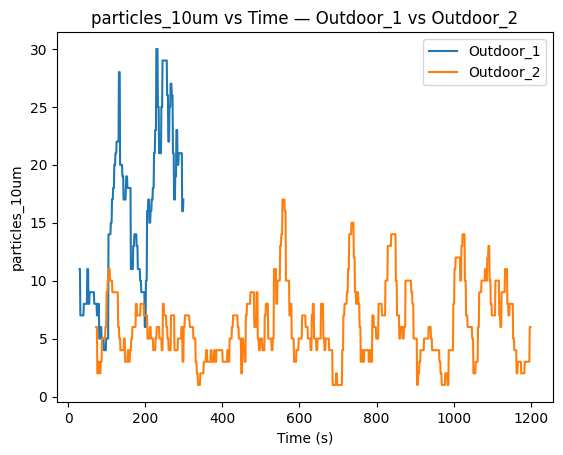

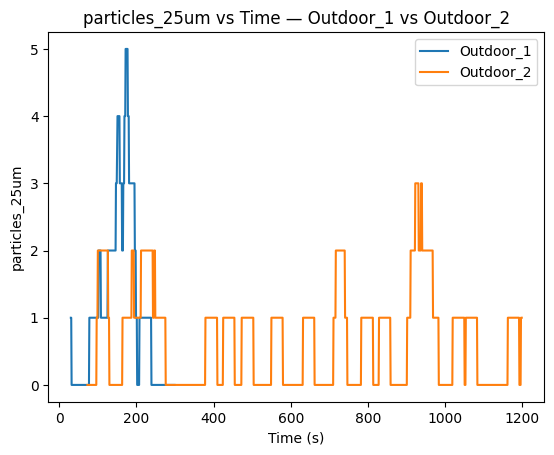

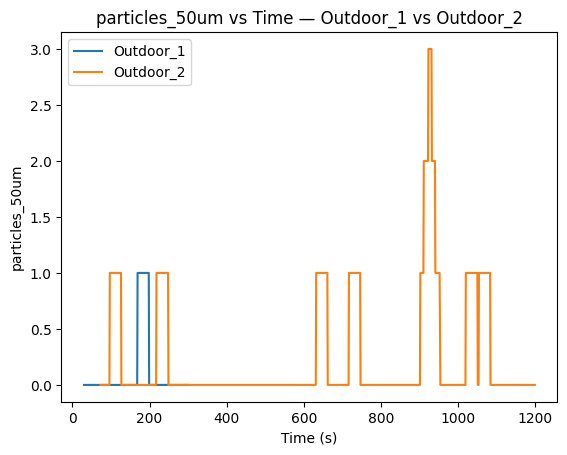

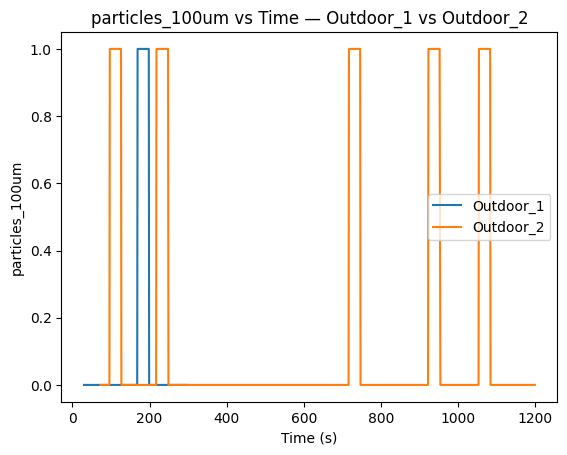

In [12]:
# Step 3 — Time series: Outdoor vs 3rd Location
for i in range(1, len(outdoor_df.columns)):
    col = outdoor_df.columns[i]
    plt.figure(400 + i)
    plt.plot(outdoor_df['t_s'], outdoor_df[col], label='Outdoor_1')
    plt.plot(loc3_df['t_s'],    loc3_df[col],    label='Outdoor_2')
    plt.xlabel('Time (s)')
    plt.ylabel(col)
    plt.legend()
    plt.title(f'{col} vs Time — Outdoor_1 vs Outdoor_2')


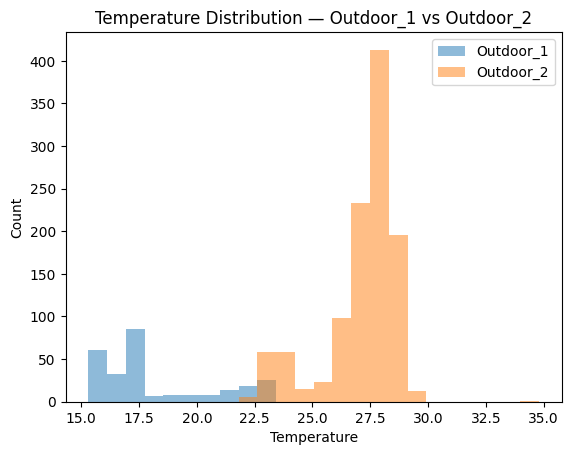

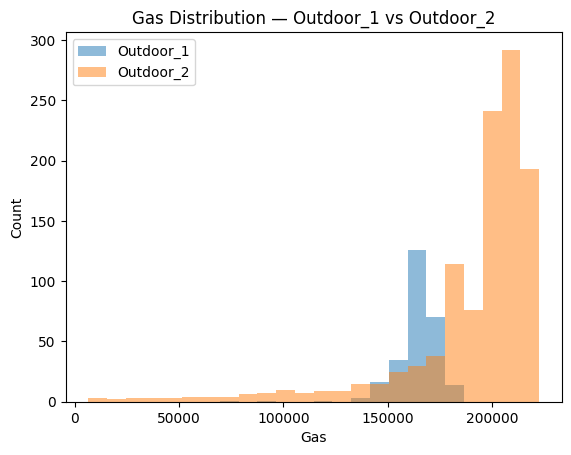

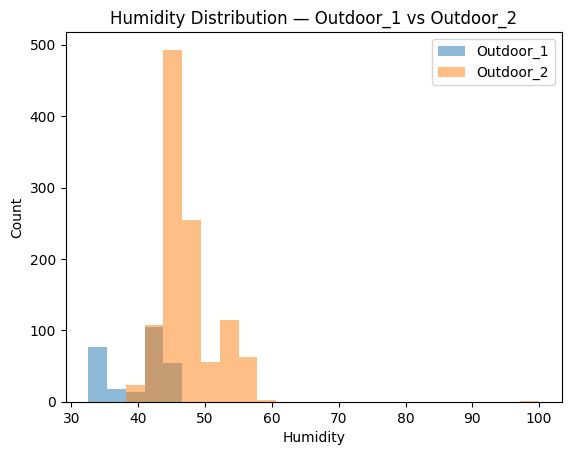

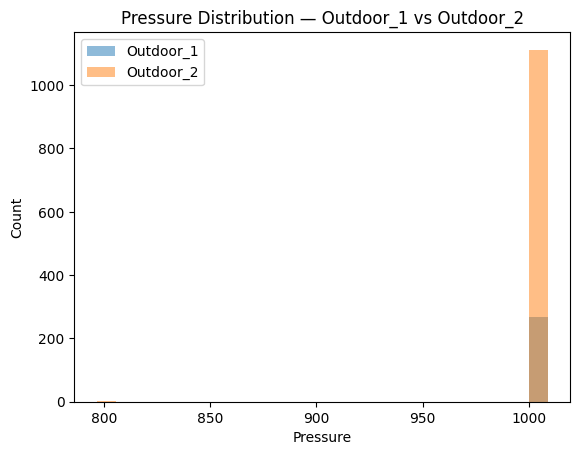

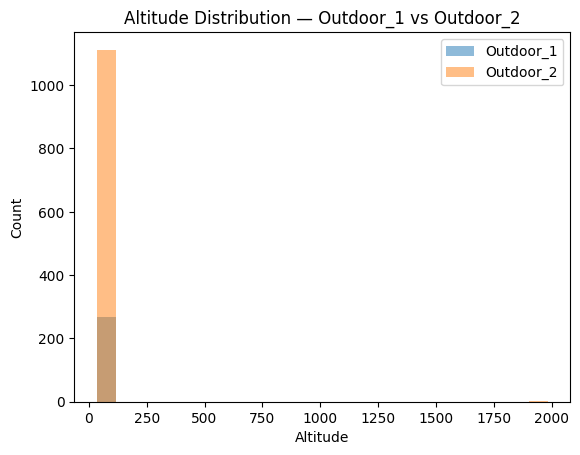

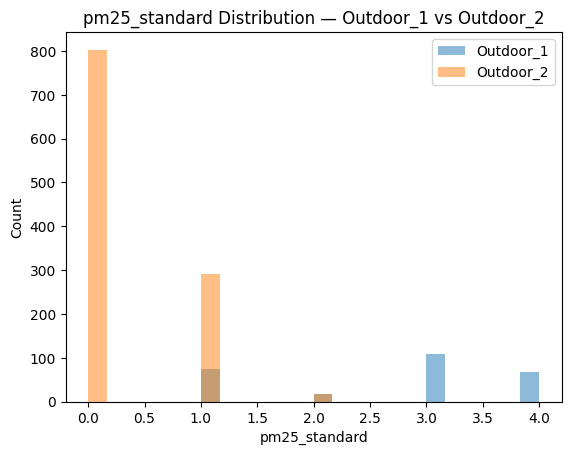

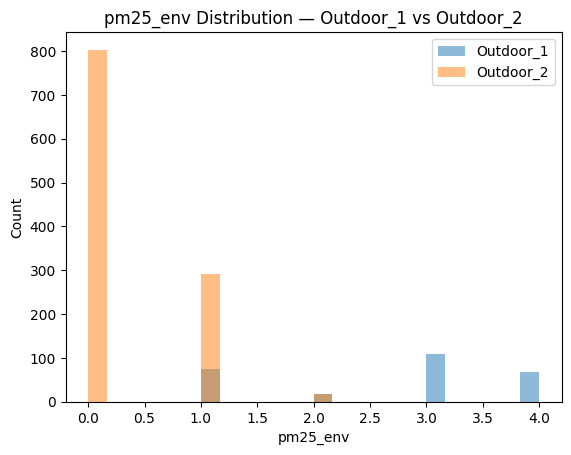

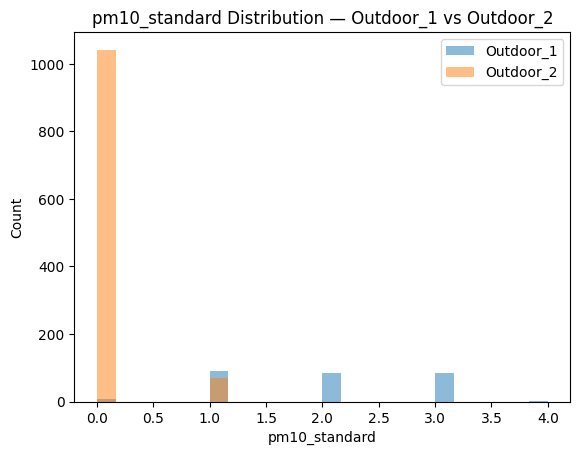

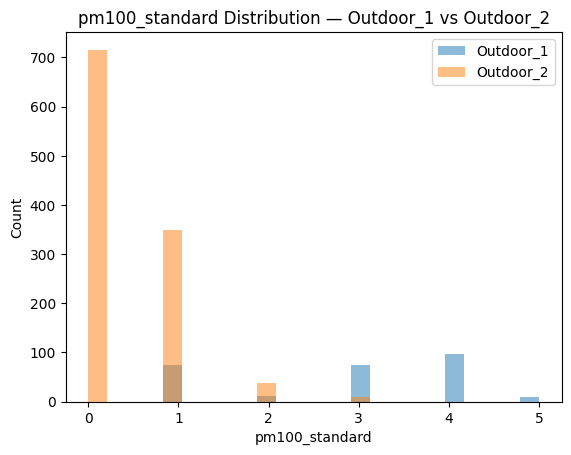

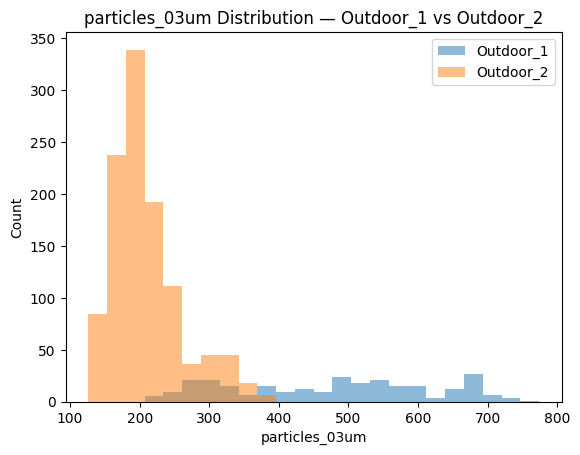

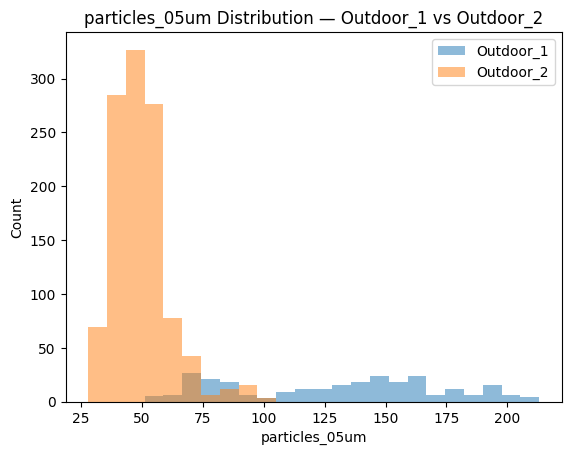

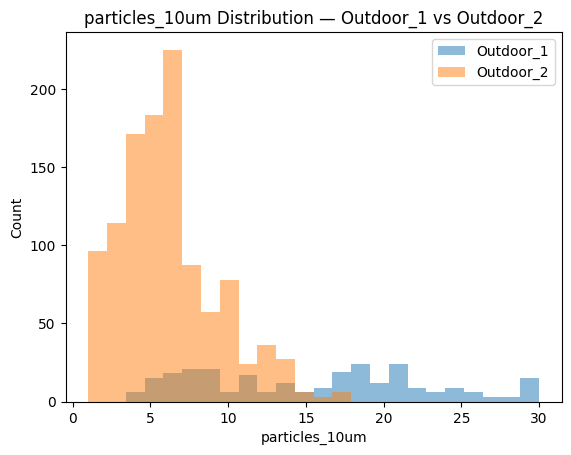

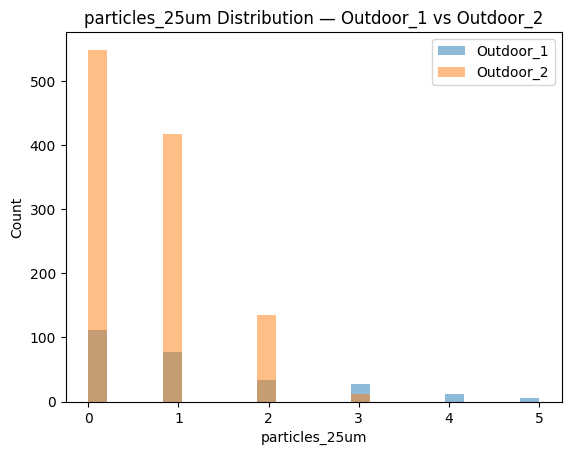

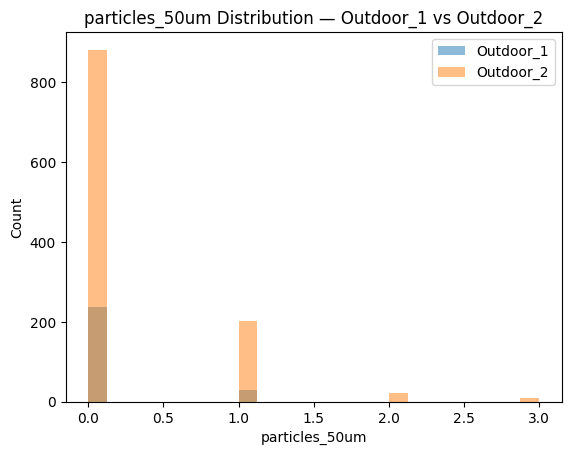

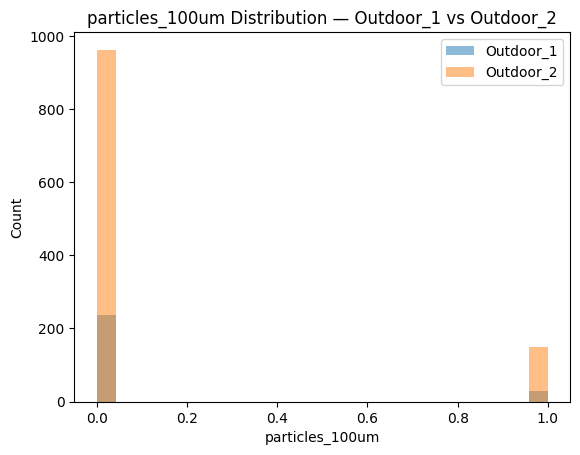

In [13]:
# Step 3 — Histograms: Outdoor vs 3rd Location
for i in range(1, len(outdoor_df.columns)):
    col = outdoor_df.columns[i]
    combined_min = min(outdoor_df[col].min(), loc3_df[col].min())
    combined_max = max(outdoor_df[col].max(), loc3_df[col].max())
    bins = np.linspace(combined_min, combined_max, 25)
    plt.figure(500 + i)
    plt.hist(outdoor_df[col], bins=bins, alpha=0.5, label='Outdoor_1')
    plt.hist(loc3_df[col],    bins=bins, alpha=0.5, label='Outdoor_2')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()
    plt.title(f'{col} Distribution — Outdoor_1 vs Outdoor_2')


In [14]:
# Step 3 — Statistical comparison: Outdoor vs 3rd Location
print("=== Outdoor vs 3rd Location Statistical Comparison ===\n")
for i in range(1, len(outdoor_df.columns)):
    col = outdoor_df.columns[i]
    mean_out  = np.mean(outdoor_df[col]);  std_out  = np.std(outdoor_df[col])
    mean_loc3 = np.mean(loc3_df[col]);     std_loc3 = np.std(loc3_df[col])
    unc_out   = std_out  / np.sqrt(len(outdoor_df))
    unc_loc3  = std_loc3 / np.sqrt(len(loc3_df))
    sep = abs(mean_out - mean_loc3) / np.sqrt(unc_out**2 + unc_loc3**2)
    print(f'{col}:')
    print(f'  Outdoor      mean={mean_out:.4f}  std={std_out:.4f}  σ_mean={unc_out:.5f}')
    print(f'  3rd Location mean={mean_loc3:.4f}  std={std_loc3:.4f}  σ_mean={unc_loc3:.5f}')
    print(f'  Separation = {sep:.2f} σ\n')


=== Outdoor vs 3rd Location Statistical Comparison ===

Temperature:
  Outdoor      mean=18.2011  std=2.4720  σ_mean=0.15128
  3rd Location mean=27.1171  std=1.5677  σ_mean=0.04699
  Separation = 56.28 σ

Gas:
  Outdoor      mean=163442.6479  std=11384.8959  σ_mean=696.74432
  3rd Location mean=190911.6649  std=34244.8948  σ_mean=1026.47471
  Separation = 22.14 σ

Humidity:
  Outdoor      mean=39.6052  std=4.3440  σ_mean=0.26585
  3rd Location mean=47.2524  std=4.0550  σ_mean=0.12155
  Separation = 26.16 σ

Pressure:
  Outdoor      mean=1006.3355  std=0.5479  σ_mean=0.03353
  3rd Location mean=1007.7793  std=6.3962  σ_mean=0.19172
  Separation = 7.42 σ

Altitude:
  Outdoor      mean=57.7286  std=4.5870  σ_mean=0.28072
  3rd Location mean=45.8045  std=58.5870  σ_mean=1.75612
  Separation = 6.70 σ

pm25_standard:
  Outdoor      mean=2.6292  std=1.1356  σ_mean=0.06949
  3rd Location mean=0.2947  std=0.4901  σ_mean=0.01469
  Separation = 32.87 σ

pm25_env:
  Outdoor      mean=2.6292  std=1

### Step 3 Discussion — Strawberry Creek vs Original Outdoor Site

Nearly all quantities are statistically different from the original outdoor dataset at well beyond 3σ:

**Temperature:** The Strawberry Creek recording was significantly warmer (27.1°C vs. 18.2°C, 56σ). This most likely reflects a different time of recording rather than a location-driven effect. The creek corridor would not intrinsically be ~9°C warmer than the building entrance.

**Humidity:** Strawberry Creek has higher humidity (47.3% vs. 39.6%, 26σ). This is physically plausible for a creek environment, where evaporation from the water surface raises local relative humidity above the broader campus baseline.

**Air quality (PM2.5 and particles):** The most notable result, the Strawberry Creek site shows significantly lower particle counts (PM2.5: 0.29 vs. 2.63 µg/m³, 33σ; particles 0.3µm: 209 vs. 474, 30σ). The original outdoor site near the lab building entrance is closer to vehicle-traffic areas, likely explaining its roughly 9× higher PM2.5. Strawberry Creek, as a pedestrian-only greenway without nearby road traffic, has correspondingly lower particulate levels. Proximity to vehicle traffic is a dominant driver of particulate pollution, and the creek environment shows this clearly by contrast.

**Gas:** Moderately higher at Strawberry Creek (191 kΩ vs. 163 kΩ, 22σ), possibly reflecting lower VOC concentrations away from traffic exhaust.

**Summary:** The two outdoor datasets are statistically distinguishable across almost all quantities. The original outdoor site near the building entrance had significantly more particulate matter than Strawberry Creek, consistent with vehicle-traffic emissions being the primary PM2.5 source in our measurements.

---
## Lab 6 Step 4 — Correlations in Data

We plot each sensor quantity against Temperature to look for correlations. Since all measurements were taken by the same combined sensor system at the same time, every row shares the same `t_s` timestamp, so plotting one quantity directly against another is valid.

**Hidden variable:** Time is the key hidden variable. Both temperature and humidity change over the recording session (e.g., as the room warms up), so they appear correlated without one necessarily causing the other.

**Quantifying correlation:** We use the Pearson $R^2$ linear correlation coefficient. $R^2$ close to 1 indicates a strong linear relationship; near 0 means no linear correlation.

### Step 4 Discussion — Correlation Results

**Temperature vs Humidity** (R ≈ −0.67, R² ≈ 0.45): Moderate negative correlation, as indoor temperature rises, relative humidity falls. Physically expected: warmer air can hold more water vapour, so relative humidity drops even at constant absolute water content. Approximately linear within the narrow indoor temperature range observed.

**Temperature vs Gas** (R ≈ +0.63, R² ≈ 0.39): Moderate positive correlation. The BME680's metal-oxide resistance is temperature-sensitive — this is largely a sensor artifact rather than a true air quality change.

**Temperature vs Pressure** (R² ≈ 0.003, not significant): No meaningful correlation. Pressure is set by atmospheric conditions, independent of room temperature.

**Temperature vs PM2.5 / Particle counts** (R² < 0.025 for all): No meaningful correlation. Particulate concentration is driven by air exchange and particle sources, independent of temperature. Time-matching between the BME680 and PMS5003 is ensured because both are polled in the same acquisition loop and share the `t_s` column — no separate synchronization needed.

**Overall:** The strongest correlations (humidity and gas, R² ~0.4–0.5) are moderate rather than strong, meaning temperature explains roughly 40–45% of their variance. Particle counts show essentially no linear relationship with temperature.


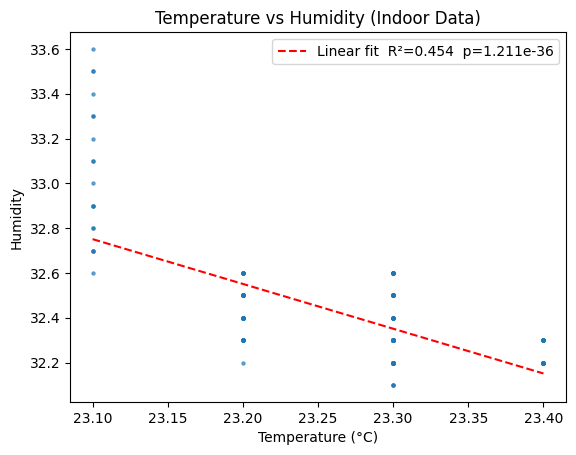

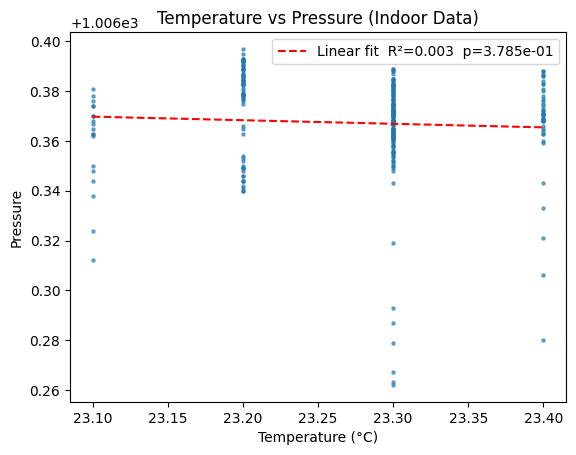

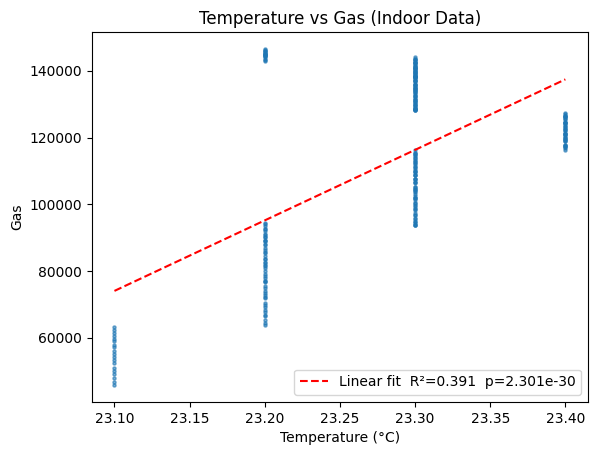

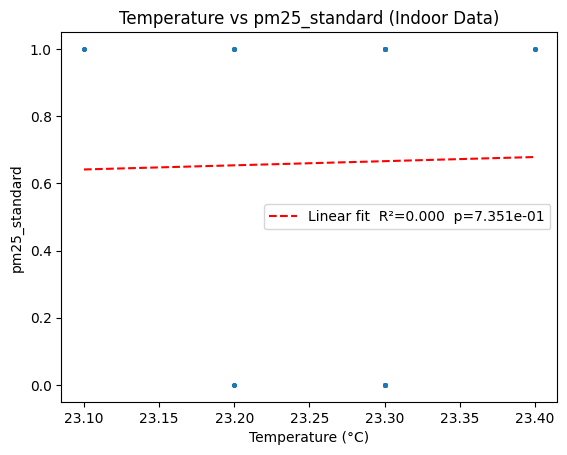

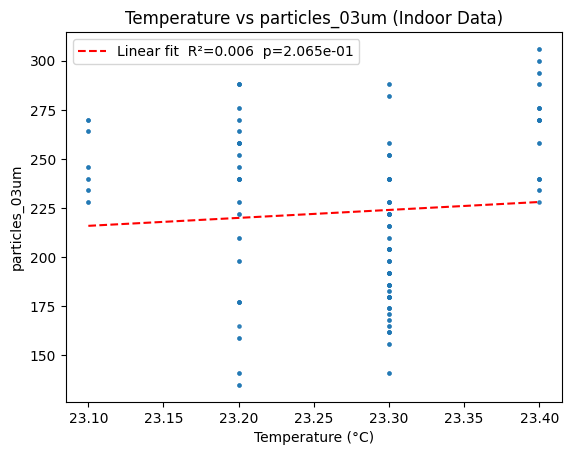

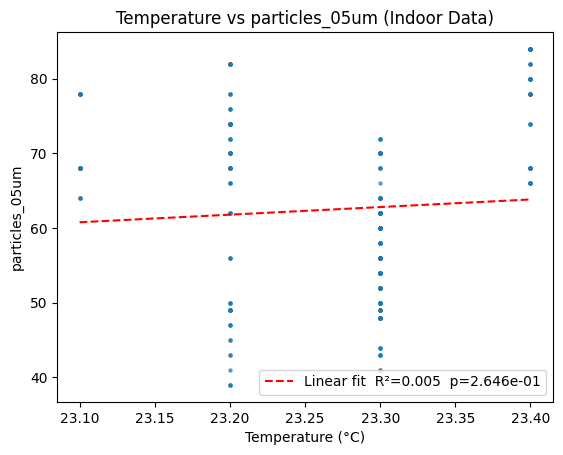

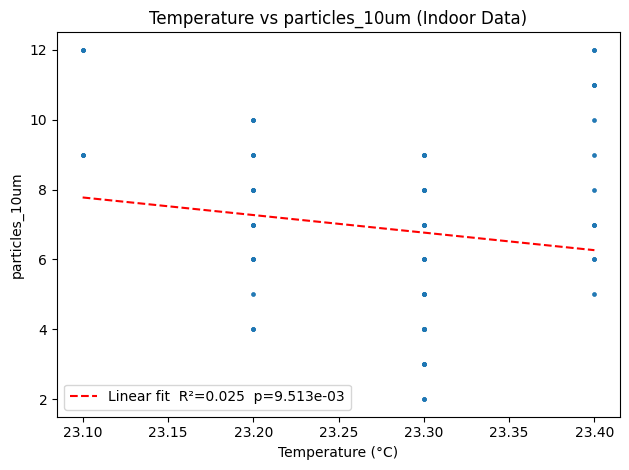

In [15]:
from scipy import stats

# Columns to correlate against Temperature (using combined indoor data)
corr_cols = ['Humidity', 'Pressure', 'Gas', 'pm25_standard',
             'particles_03um', 'particles_05um', 'particles_10um']

temp = indoor_df['Temperature']

fig_offset3 = 300
for idx, col in enumerate(corr_cols):
    y = indoor_df[col]
    r, pval = stats.pearsonr(temp, y)
    plt.figure(fig_offset3 + idx)
    plt.scatter(temp, y, s=5, alpha=0.6)
    # Fit line
    m, b = np.polyfit(temp, y, 1)
    x_line = np.linspace(temp.min(), temp.max(), 100)
    plt.plot(x_line, m * x_line + b, 'r--', label=f'Linear fit  R²={r**2:.3f}  p={pval:.3e}')
    plt.xlabel('Temperature (°C)')
    plt.ylabel(col)
    plt.legend()
    plt.title(f'Temperature vs {col} (Indoor Data)')

plt.tight_layout()


In [16]:
# --- Summary: Pearson R² for Temperature vs all quantities ---
print("Pearson R² Correlation with Temperature (Indoor Data)\n")
print(f"{'Column':<25}  {'R':>8}  {'R²':>8}  {'p-value':>12}")
print("-" * 58)
for col in corr_cols:
    r, pval = stats.pearsonr(indoor_df['Temperature'], indoor_df[col])
    print(f"{col:<25}  {r:>8.4f}  {r**2:>8.4f}  {pval:>12.3e}")

print("\n--- Temperature vs PM2.5 note ---")
print("PM2.5 and temperature are both recorded in the same row of the CSV,")
print("collected by the same combined script at the same timestamp.")
print("No additional time-matching is required since the data shares a single t_s column.")


Pearson R² Correlation with Temperature (Indoor Data)

Column                            R        R²       p-value
----------------------------------------------------------
Humidity                    -0.6735    0.4536     1.211e-36
Pressure                    -0.0541    0.0029     3.785e-01
Gas                          0.6252    0.3909     2.301e-30
pm25_standard                0.0208    0.0004     7.351e-01
particles_03um               0.0776    0.0060     2.065e-01
particles_05um               0.0685    0.0047     2.646e-01
particles_10um              -0.1584    0.0251     9.513e-03

--- Temperature vs PM2.5 note ---
PM2.5 and temperature are both recorded in the same row of the CSV,
collected by the same combined script at the same timestamp.
No additional time-matching is required since the data shares a single t_s column.
